# Original GMU Static–Dynamic Crime Forecasting (No GNN)

This notebook preserves the original data loading, feature extraction, smoothing,
normalization, temporal split, node split utilities, and PyG datasets. Only the
model and post-model analyses are replaced.

The model uses the established **Gated Multimodal Unit (GMU)** to fuse static
socioeconomic features and a dynamic crime window at every node. The resulting
joint node representation is passed directly to an MLP regressor; no graph layer is used.


## Reproducibility status

The source in this notebook has been standardized for the publication comparison. Existing saved outputs are retained as historical evidence, but they must not be combined with the updated source. Run the notebook from a clean kernel; final test metrics and explanations are valid only after the standardized best-validation checkpoint is reloaded.

The active protocol is chronological and transductive. The optional unseen-node wrapper is disabled. Case-level correlation p-values in retained historical outputs are descriptive because node-window rows are temporally clustered; publication inference must use the time-cluster bootstrap intervals and matched-seed variation. Frozen zero-input modality evaluations are ablations, not independently trained unimodal baselines.


## Architecture

For node $i$ at window $t$:

$$
\mathbf{h}^{s}_{i}=\tanh(W_s\mathbf{x}^{s}_{i}+b_s),\qquad
\mathbf{h}^{d}_{i,t}=\tanh(W_d\mathbf{x}^{d}_{i,t}+b_d),
$$

$$
\mathbf{z}_{i,t}=\sigma\left(W_z[\mathbf{x}^{s}_{i}\Vert
\mathbf{x}^{d}_{i,t}]+b_z\right),
$$

$$
\mathbf{h}^{GMU}_{i,t}=\mathbf{z}_{i,t}\odot\mathbf{h}^{s}_{i}
+(1-\mathbf{z}_{i,t})\odot\mathbf{h}^{d}_{i,t}.
$$

$\mathbf{z}_{i,t}$ is a feature-wise gate: values near 1 favor the static
representation and values near 0 favor the dynamic representation. The fused
representation is passed directly to an MLP regressor. There is no graph message
passing in this original GMU-only baseline.


## What remains unchanged

- Static and dynamic feature selection
- Exponential smoothing and log transformation
- Train-only normalization
- Sliding-window dataset construction
- Existing temporal and node-split setup

The replacement section contains the GMU-GNN, leakage-free fixed-epoch training,
evaluation, gate analysis, modality ablation, neighborhood time-series plots,
gradient sensitivity, and embedding visualization.


In [1]:
import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, SAGEConv, GATConv, GraphConv
from torch_geometric.data import Data
import optuna
import pandas as pd
import numpy as np
import torch.nn as nn
import os
import matplotlib.pyplot as plt
import re
from sklearn.preprocessing import MinMaxScaler
import seaborn as sns
from sklearn.manifold import TSNE


from helper_funcs import *
from plots import *
from models import *
from model_helper_funcs import *
from model_fusion_scratch import *
from torch_geometric.loader import DataLoader as PyGDataLoader


c:\Users\waqar\AppData\Local\pypoetry\Cache\virtualenvs\data-fusion-r9UYRqEp-py3.12\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Configuration


In [2]:
seed = 42
set_seed(seed)

num_epochs = 50

data_set = "real"         # "real" | "artificial"
type_graph_conv = 'GMU_orig'  # StaticDynamicGNN_hidden "SAGE" | "GCN" | "GAT" | "FWAGCN" | "EFWAGCN" | "GraphConv" |DualGNN | StaticDynamicGNN_adv
architecture = "2_layers"

# if type_graph_conv == 'SAGE':
#     graph_conv = SAGEConv
# elif type_graph_conv == "GCN":
#     graph_conv = GCNConv
# elif type_graph_conv == "GAT":
#     graph_conv = GATConv
# elif type_graph_conv == "FWAGCN":
#     graph_conv = FeatureWiseGraphConv
# elif type_graph_conv == "EFWAGCN":
#     graph_conv = EdgeFeatureAttentionGCN
# elif type_graph_conv == "GraphConv":
#     graph_conv = GraphConv
# elif type_graph_conv == "DualGNN":
#     graph_conv = DualGNN
    
    
# model_used is standardized below.

# output_folder is standardized below.


# Publication-comparison standardization (source update; rerun required).
model_used = 'Original_GMU_Only_Complete_Explainability'
results_root = os.path.join("results", model_used)
checkpoint_dir = os.path.join(results_root, "checkpoints")
plot_dir = os.path.join(results_root, "plots")
csv_dir = os.path.join(results_root, "csv")
for directory in (results_root, checkpoint_dir, plot_dir, csv_dir):
    os.makedirs(directory, exist_ok=True)

# Backward-compatible destination for existing analysis cells.
output_folder = results_root
execution_status = "SOURCE_UPDATED_REQUIRES_CLEAN_RERUN"
split_type = "chronological_transductive"
prediction_horizon = 1
validation_fraction = 0.20
max_epochs = 250
patience = 20
min_delta = 1e-7
batch_size = 1
comparison_seeds = [42, 43, 44, 45, 46]

def standardized_checkpoint(
    model, optimizer, best_epoch, best_validation_loss,
    train_loss_history, validation_loss_history,
    best_model_state=None, best_optimizer_state=None,
    diagnostic_histories=None,
):
    """Build the common, reloadable comparison checkpoint."""
    import torch_geometric
    model_state = best_model_state if best_model_state is not None else model.state_dict()
    optimizer_state_matches_best_epoch = best_optimizer_state is not None
    optimizer_state = (
        best_optimizer_state if best_optimizer_state is not None
        else optimizer.state_dict()
    )
    static_names = list(static_dt.columns) if "static_dt" in globals() else []
    dynamic_names = list(dynamic_cols) if "dynamic_cols" in globals() else []
    train_at_best = None
    if best_epoch and len(train_loss_history) >= best_epoch:
        train_at_best = float(train_loss_history[best_epoch - 1])
    return {
        "schema_version": 1,
        "model_name": model_used,
        "architecture_name": type(model).__name__,
        "model_class": type(model).__name__,
        "model_config": {
            "static_dim": int(static_tensor.shape[1]),
            "dynamic_dim": int(W),
            "window_size": int(W),
            "prediction_horizon": int(prediction_horizon),
        },
        "model_state_dict": model_state,
        "optimizer_name": type(optimizer).__name__,
        "optimizer_config": {
            "lr": float(optimizer.param_groups[0]["lr"]),
            "weight_decay": float(optimizer.param_groups[0].get("weight_decay", 0.0)),
        },
        "optimizer_state_dict": optimizer_state,
        "optimizer_state_matches_best_epoch": optimizer_state_matches_best_epoch,
        "best_epoch": int(best_epoch),
        "best_validation_loss": float(best_validation_loss),
        "train_loss_at_best_epoch": train_at_best,
        "train_loss_history": list(train_loss_history),
        "validation_loss_history": list(validation_loss_history),
        "diagnostic_histories": diagnostic_histories or {},
        "seed": int(seed),
        "dataset_path": str(name_file_dataset),
        "edge_path": "datasets/aristas_subgrafoSPdaily.csv",
        "static_feature_names": static_names,
        "dynamic_column_names": dynamic_names,
        "static_dim": int(static_tensor.shape[1]),
        "dynamic_dim": int(W),
        "window_size": int(W),
        "prediction_horizon": int(prediction_horizon),
        "preprocessing_config": {
            "smoothing": "EWM",
            "ewm_alpha": 0.1,
            "transform": "log1p",
            "missing_values": "torch.nan_to_num(nan=0.0)",
            "static_scaler": "MinMaxScaler_fit_on_training_nodes",
            "dynamic_scaler": "global_minmax_fit_on_training_nodes_and_training_times",
        },
        "split_config": {
            "type": split_type,
            "train_end": int(TRAIN_END),
            "validation_fraction": float(validation_fraction),
            "fit_windows": len(fit_dataset),
            "validation_windows": len(validation_dataset),
            "test_windows": len(test_dataset),
        },
        "train_node_ids": train_nodes.detach().cpu(),
        "test_node_ids": test_nodes.detach().cpu(),
        "parameter_count": int(sum(p.numel() for p in model.parameters() if p.requires_grad)),
        "pytorch_version": torch.__version__,
        "pyg_version": torch_geometric.__version__,
        "execution_status": execution_status,
    }



# Load dataset

In [3]:
if data_set == "artificial":
    print("Using artificial dataset")
    name_file_dataset = os.path.join("datasets", "artificial_data_12_clusters_full.csv")
else:
    print("Using real dataset")
    name_file_dataset = "datasets/datasubset_nodes_waqar.csv"

df_nodes = pd.read_csv(name_file_dataset)
df_edges = pd.read_csv("datasets/aristas_subgrafoSPdaily.csv")
edge_index = map_edges_new_index(df_nodes, df_edges)

Using real dataset
tensor([[    573641,     573641,     573643,  ..., 8751085661, 8753316632,
         8795904828],
        [ 465879071,  292424978,  292424978,  ..., 8751085667, 8753316633,
         8795904831]])


d:\data_fusion\helper_funcs.py:50: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  edges_mapeados = df_edges.applymap(lambda x: mapping_dict.get(x, x)).values


edge_index_mapeado ------->  tensor([[    0,     0,     1,  ..., 14575, 14578, 14596],
        [ 5698,  1381,  1381,  ..., 14576, 14579, 14597]])


In [4]:
df_nodes.shape

(14640, 159)

# Label nodes

In [5]:
df_nodes_label = label_crime_nodes(df_nodes, threshold=6)
crime_label_col = "crime_label"
num_nodes = df_nodes_label.shape[0]

In [6]:
# plot_crime_vs_nocrime_ratio(df_nodes_label)

# Extract feature groups

In [7]:
df_nodes_label.columns

Index(['Nodo', '2006.01', '2006.02', '2006.03', '2006.04', '2006.05',
       '2006.06', '2006.07', '2006.08', '2006.09',
       ...
       'maiores_de_65_anos_taxa', 'Pontos_de_onibus', 'Estacao_de_metro',
       'Estacao_de_trem', 'Terminal_de_onibus', 'Favela_proxima', 'lat',
       'long', 'total_crimes', 'crime_label'],
      dtype='object', length=161)

In [8]:
dynamic_cols = sorted([col for col in df_nodes_label.columns if re.match(r'^\d{4}\.\d{2}$', col)])
dynamic_dt = df_nodes_label[dynamic_cols]

cols_to_drop = dynamic_cols + ['Nodo', 'Pontos_de_onibus', 'lat', 'long', 'total_crimes', 'crime_label']
static_dt = df_nodes_label.drop(columns=cols_to_drop)

In [9]:
crime_label_col = df_nodes_label['crime_label']
crime_label_col

0        1
1        1
2        1
3        1
4        0
        ..
14635    0
14636    0
14637    0
14638    0
14639    0
Name: crime_label, Length: 14640, dtype: int64

In [10]:
static_dt.shape

(14640, 11)

# Normalize features


# Smooth dynamic data

In [11]:
dynamic_dt_smooth = dynamic_dt.apply(lambda row: row.ewm(alpha=0.1).mean(), axis=1)
dynamic_dt_smooth_log = np.log1p(np.array(dynamic_dt_smooth))

# global_min = dynamic_dt_smooth_log.min().min()
# global_max = dynamic_dt_smooth_log.max().max()
# dynamic_dt_norm = pd.DataFrame((dynamic_dt_smooth_log - global_min) / (global_max - global_min))

dynamic_dt_smooth_log = pd.DataFrame(dynamic_dt_smooth_log)
static_dt = pd.DataFrame(static_dt)

# scaler = MinMaxScaler()

# static_dt_norm = pd.DataFrame(scaler.fit_transform(static_dt))

# Convert to tensors

In [12]:
dynamic_tensor = torch.tensor(dynamic_dt_smooth_log.values, dtype=torch.float32)
dynamic_tensor = torch.nan_to_num(dynamic_tensor, nan=0.0)

static_tensor = torch.tensor(static_dt.values, dtype=torch.float32)
static_tensor = torch.nan_to_num(static_tensor, nan=0.0)

In [13]:
print(dynamic_tensor.shape)
print(static_tensor.shape)

torch.Size([14640, 144])
torch.Size([14640, 11])


# Sliding Window approach

In [14]:
# # Time split
TRAIN_END = 100
T = dynamic_tensor.size(1)
W = 5

# train_dataset = CrimeWindowPyGDataset(
# # train_dataset = CrimeWindowDataset(
#     static_tensor, dynamic_tensor, edge_index,
#     window_size=W,
#     start_t=0,
#     end_t=TRAIN_END
# )

# test_dataset = CrimeWindowPyGDataset(
# # test_dataset = CrimeWindowDataset(
#     static_tensor, dynamic_tensor, edge_index,
#     window_size=W,
#     start_t=TRAIN_END,
#     end_t=T
# )



# Optional unseen-node inductive workflow (disabled)

In [15]:
import torch

def filter_and_reindex(data, allowed_nodes):

    # ---- Step 1: mask nodes ----
    mask = torch.isin(data.node_ids, allowed_nodes)

    if mask.sum() == 0:
        return None

    # ---- Step 2: filter node features ----
    new_x_static = data.x_static[mask]
    new_x_dynamic = data.x_dynamic[mask]
    new_y = data.y[mask]

    # IMPORTANT: keep original node ids temporarily
    old_node_ids = data.node_ids[mask]

    # ---- Step 3: create mapping old → new index ----
    # Example: {5:0, 10:1, 20:2}
    unique_nodes = old_node_ids
    mapping = {int(old_id): i for i, old_id in enumerate(unique_nodes)}

    # ---- Step 4: filter edges ----
    src, dst = data.edge_index

    edge_mask = torch.isin(src, old_node_ids) & torch.isin(dst, old_node_ids)

    src = src[edge_mask]
    dst = dst[edge_mask]

    # ---- Step 5: reindex edges ----
    new_src = torch.tensor([mapping[int(s)] for s in src])
    new_dst = torch.tensor([mapping[int(d)] for d in dst])

    new_edge_index = torch.stack([new_src, new_dst], dim=0)

    # ---- Step 6: create new node ids (0...N-1) ----
    new_node_ids = torch.arange(len(unique_nodes))

    # ---- Step 7: update time_id ----
    new_time_id = data.time_id[mask]

    # ---- Step 8: return new Data ----
    new_data = data.clone()

    new_data.x_static = new_x_static
    new_data.x_dynamic = new_x_dynamic
    new_data.y = new_y
    new_data.edge_index = new_edge_index
    new_data.original_node_ids = old_node_ids.clone()  # preserve global identity
    new_data.node_ids = new_node_ids   # ✅ reindexed
    new_data.time_id = new_time_id
    new_data.num_nodes = len(new_node_ids)

    return new_data

from torch.utils.data import Dataset

class InductiveWrapperDataset(Dataset):
    def __init__(self, base_dataset, allowed_nodes):
        self.base_dataset = base_dataset
        self.allowed_nodes = allowed_nodes

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, idx):

        data = self.base_dataset[idx]

        new_data = filter_and_reindex(data, self.allowed_nodes)

        # Handle rare empty case
        if new_data is None:
            return self.__getitem__((idx + 1) % len(self))

        return new_data
    
    import numpy as np

def split_nodes(num_nodes, train_ratio=0.8, seed=42):
    np.random.seed(seed)

    nodes = np.arange(num_nodes)
    np.random.shuffle(nodes)

    split = int(train_ratio * num_nodes)

    train_nodes = torch.tensor(nodes[:split])
    test_nodes = torch.tensor(nodes[split:])

    return train_nodes, test_nodes

## Split nodes

In [16]:
train_nodes, test_nodes = split_nodes(static_tensor.shape[0])

## Compute normalization ONLY from TRAIN

Dynamic normalization

In [17]:
train_dynamic = dynamic_tensor[train_nodes][:, :TRAIN_END]

min_val = train_dynamic.min()
max_val = train_dynamic.max()

dynamic_tensor_norm = (dynamic_tensor - min_val) / (max_val - min_val + 1e-8)

In [18]:
dynamic_tensor.max()

tensor(3.8104)

Static normalization

In [19]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

train_static = static_tensor[train_nodes]

scaler.fit(train_static)

static_tensor_norm = torch.tensor(
    scaler.transform(static_tensor),
    dtype=torch.float32
)

Temporal Split

In [20]:
train_dataset = CrimeWindowPyGDataset(
    static_tensor_norm,
    dynamic_tensor_norm,
    edge_index,
    window_size=W,
    start_t=0,
    end_t=TRAIN_END
)

test_dataset = CrimeWindowPyGDataset(
    static_tensor_norm,
    dynamic_tensor_norm,
    edge_index,
    window_size=W,
    start_t=TRAIN_END,
    end_t=T
)
# Active protocol: chronological and transductive. The optional
# InductiveWrapperDataset is intentionally not applied here.
split_type = "chronological_transductive"


# Active chronological transductive split

In [21]:

# train_dataset = InductiveWrapperDataset(train_dataset, train_nodes)
# test_dataset = InductiveWrapperDataset(test_dataset, test_nodes)

In [22]:
sample = train_dataset[0]

print(sample.x_static.shape)
print(sample.edge_index.max(), sample.num_nodes)

torch.Size([14640, 11])
tensor(14639) 14640


In [23]:
sample = test_dataset[0]

print(sample.x_dynamic.shape)
print(sample.edge_index.max(), sample.num_nodes)

torch.Size([14640, 5])
tensor(14639) 14640


# Original GMU fusion model (No GNN)

The GMU is applied independently at every node and time window. Its fused
representation is passed directly to an MLP regressor. `edge_index` is accepted
only for interface compatibility and is not used. This is the original GMU-only
baseline, not GMU-GNN.


In [24]:
import torch
import torch.nn as nn


class GatedMultimodalUnit(nn.Module):
    """Original feature-wise GMU for static and dynamic modalities."""

    def __init__(self, static_dim, dynamic_dim, hidden_dim):
        super().__init__()
        self.static_encoder = nn.Linear(static_dim, hidden_dim)
        self.dynamic_encoder = nn.Linear(dynamic_dim, hidden_dim)
        self.gate_layer = nn.Linear(static_dim + dynamic_dim, hidden_dim)
        self.norm1 = nn.LayerNorm(hidden_dim)
        self.reset_parameters()

    def reset_parameters(self):
        for layer in (
            self.static_encoder,
            self.dynamic_encoder,
            self.gate_layer,
        ):
            nn.init.xavier_uniform_(layer.weight)
            nn.init.zeros_(layer.bias)

    def forward(self, x_static, x_dynamic):
        h_static = torch.tanh(self.static_encoder(x_static))
        h_dynamic = torch.tanh(self.dynamic_encoder(x_dynamic))
        gate_static = torch.sigmoid(
            self.gate_layer(torch.cat([x_static, x_dynamic], dim=-1))
        )
        h_fused = (
            gate_static * h_static
            + (1.0 - gate_static) * h_dynamic
        )
        h_fused = self.norm1(F.relu(h_fused))
        return h_fused, gate_static, h_static, h_dynamic


class GMUForecastModel(nn.Module):
    """Original GMU fusion followed by an MLP regressor; no GNN layer."""

    def __init__(self, static_dim, dynamic_dim, hidden_dim=64, dropout=0.2):
        super().__init__()
        self.gmu = GatedMultimodalUnit(
            static_dim=static_dim,
            dynamic_dim=dynamic_dim,
            hidden_dim=hidden_dim,
        )
        self.regressor = nn.Sequential(
            nn.Linear(hidden_dim, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 1),
        )

    def forward(self, x_static, x_dynamic, edge_index=None, return_details=False):
        # edge_index is intentionally accepted only to keep every existing
        # training and analysis function unchanged. GMU does not use the graph.
        h_gmu, gate, h_static, h_dynamic = self.gmu(
            x_static,
            x_dynamic,
        )
        prediction = self.regressor(h_gmu).squeeze(-1)

        if return_details:
            return prediction, h_gmu, {
                "gate": gate,
                "h_static": h_static,
                "h_dynamic": h_dynamic,
                "h_gmu": h_gmu,
            }
        return prediction, h_gmu


# Model initialization


In [25]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
S = static_tensor.size(1)

model = GMUForecastModel(
    static_dim=S,
    dynamic_dim=W,
    hidden_dim=64,
    dropout=0.6,
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
criterion = nn.MSELoss()

train_loader = PyGDataLoader(train_dataset, batch_size=1, shuffle=True)
test_loader = PyGDataLoader(test_dataset, batch_size=1, shuffle=False)

print(model)
print("Device:", device)
print("Trainable parameters:", sum(p.numel() for p in model.parameters() if p.requires_grad))


GMUForecastModel(
  (gmu): GatedMultimodalUnit(
    (static_encoder): Linear(in_features=11, out_features=64, bias=True)
    (dynamic_encoder): Linear(in_features=5, out_features=64, bias=True)
    (gate_layer): Linear(in_features=16, out_features=64, bias=True)
    (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  )
  (regressor): Sequential(
    (0): Linear(in_features=64, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.6, inplace=False)
    (3): Linear(in_features=128, out_features=1, bias=True)
  )
)
Device: cpu
Trainable parameters: 10817


# Validation set

In [26]:
from torch.utils.data import Subset

# Chronological validation is taken only from the existing training windows.
# The untouched test_dataset is never used for checkpoint selection.
validation_fraction = 0.20
num_development_windows = len(train_dataset)
num_validation_windows = max(1, int(np.ceil(validation_fraction * num_development_windows)))
validation_start = num_development_windows - num_validation_windows

fit_dataset = Subset(train_dataset, range(0, validation_start))
validation_dataset = Subset(train_dataset, range(validation_start, num_development_windows))

train_loader = PyGDataLoader(fit_dataset, batch_size=1, shuffle=True)
validation_loader = PyGDataLoader(validation_dataset, batch_size=1, shuffle=False)
test_loader = PyGDataLoader(test_dataset, batch_size=1, shuffle=False)

print("Fit windows:", len(fit_dataset))
print("Validation windows:", len(validation_dataset))
print("Untouched test windows:", len(test_dataset))

Fit windows: 76
Validation windows: 19
Untouched test windows: 39


# Training

Because the supplied preprocessing creates only training and test datasets,
the model is trained for the configured fixed number of epochs. The test set is
not used for early stopping or checkpoint selection.


In [27]:
def _move_batch(data, device):
    return data.to(device)


def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    total_nodes = 0
    static_gate_sum = 0.0
    gate_elements = 0

    for data in loader:
        data = _move_batch(data, device)
        optimizer.zero_grad()
        prediction, _, details = model(
            data.x_static, data.x_dynamic, data.edge_index, return_details=True
        )
        target = data.y.float().view_as(prediction)
        loss = criterion(prediction, target)
        loss.backward()
        optimizer.step()

        n = target.numel()
        total_loss += loss.item() * n
        total_nodes += n
        static_gate_sum += details["gate"].detach().sum().item()
        gate_elements += details["gate"].numel()

    return total_loss / max(total_nodes, 1), static_gate_sum / max(gate_elements, 1)


@torch.no_grad()
def evaluate_validation(
    model,
    loader,
    criterion,
    device
):
    model.eval()

    total_loss = 0.0
    total_nodes = 0

    static_gate_sum = 0.0
    gate_elements = 0

    for data in loader:
        data = _move_batch(
            data,
            device
        )

        prediction, _, details = model(
            data.x_static,
            data.x_dynamic,
            data.edge_index,
            return_details=True,
        )

        target = data.y.float().view_as(
            prediction
        )

        loss = criterion(
            prediction,
            target
        )

        n = target.numel()

        total_loss += loss.item() * n
        total_nodes += n

        static_gate_sum += (
            details["gate"]
            .detach()
            .sum()
            .item()
        )

        gate_elements += (
            details["gate"].numel()
        )

    validation_loss = (
        total_loss
        / max(total_nodes, 1)
    )

    validation_static_gate = (
        static_gate_sum
        / max(gate_elements, 1)
    )

    return (
        validation_loss,
        validation_static_gate,
    )


In [28]:
import copy
import os
import numpy as np
import torch


# --------------------------------------------------
# Training configuration
# --------------------------------------------------

max_epochs = 250

patience = 20

# Your MSE values are small, so use a sufficiently
# small minimum-improvement threshold.
min_delta = 1e-7


checkpoint_path = (
    "best_original_gmu_chronological.pt"
)


# --------------------------------------------------
# Keep the original history variable names
# --------------------------------------------------

train_loss_history = []

static_gate_history = []


# --------------------------------------------------
# Validation histories
# --------------------------------------------------

validation_loss_history = []

validation_static_gate_history = []


# --------------------------------------------------
# Best-checkpoint variables
# --------------------------------------------------

best_validation_loss = float("inf")

best_epoch = 0

best_model_state = None

best_optimizer_state = None

epochs_without_improvement = 0


# --------------------------------------------------
# Training loop
# --------------------------------------------------

for epoch in range(max_epochs):

    # Train only on the earlier chronological
    # development windows.
    (
        train_loss,
        static_gate_mean,
    ) = train_one_epoch(
        model=model,
        loader=train_loader,
        optimizer=optimizer,
        criterion=criterion,
        device=device,
    )

    # Select the checkpoint using the later
    # chronological validation windows.
    (
        validation_loss,
        validation_static_gate_mean,
    ) = evaluate_validation(
        model=model,
        loader=validation_loader,
        criterion=criterion,
        device=device,
    )

    # Preserve variables used by later notebook cells.
    train_loss_history.append(
        train_loss
    )

    static_gate_history.append(
        static_gate_mean
    )

    validation_loss_history.append(
        validation_loss
    )

    validation_static_gate_history.append(
        validation_static_gate_mean
    )

    # ----------------------------------------------
    # Check for validation improvement
    # ----------------------------------------------

    if (
        validation_loss
        < best_validation_loss - min_delta
    ):
        best_validation_loss = (
            validation_loss
        )

        best_epoch = epoch + 1

        best_model_state = copy.deepcopy(
            model.state_dict()
        )

        best_optimizer_state = copy.deepcopy(
            optimizer.state_dict()
        )

        epochs_without_improvement = 0

        # Save every new best checkpoint.
        torch.save(
            {
                "model_state_dict": (
                    best_model_state
                ),

                "optimizer_state_dict": (
                    best_optimizer_state
                ),

                "best_epoch": best_epoch,

                "best_validation_loss": (
                    best_validation_loss
                ),

                "train_loss_at_best_epoch": (
                    train_loss
                ),

                "static_gate_at_best_epoch": (
                    static_gate_mean
                ),

                "validation_static_gate_at_best_epoch": (
                    validation_static_gate_mean
                ),

                "train_loss_history": (
                    train_loss_history.copy()
                ),

                "validation_loss_history": (
                    validation_loss_history.copy()
                ),

                "static_gate_history": (
                    static_gate_history.copy()
                ),

                "validation_static_gate_history": (
                    validation_static_gate_history.copy()
                ),
            },
            checkpoint_path,
        )

    else:
        epochs_without_improvement += 1

    # ----------------------------------------------
    # Print progress
    # ----------------------------------------------

    if (
        epoch == 0
        or (epoch + 1) % 10 == 0
        or epoch + 1 == max_epochs
    ):
        print(
            f"Epoch {epoch + 1:03d}/"
            f"{max_epochs} | "
            f"Train MSE: "
            f"{train_loss:.8f} | "
            f"Validation MSE: "
            f"{validation_loss:.8f} | "
            f"Best validation MSE: "
            f"{best_validation_loss:.8f} "
            f"(epoch {best_epoch}) | "
            f"Train static gate: "
            f"{static_gate_mean:.4f} | "
            f"Validation static gate: "
            f"{validation_static_gate_mean:.4f} | "
            f"Patience: "
            f"{epochs_without_improvement}/"
            f"{patience}"
        )

    # ----------------------------------------------
    # Early stopping
    # ----------------------------------------------

    if (
        epochs_without_improvement
        >= patience
    ):
        print(
            f"\nEarly stopping at epoch "
            f"{epoch + 1}."
        )

        print(
            f"Best validation MSE: "
            f"{best_validation_loss:.8f} "
            f"at epoch {best_epoch}."
        )

        break


# Save the common comparison checkpoint after restoring the selected model.
checkpoint_path = os.path.join(checkpoint_dir, f"{model_used}__seed-{seed}__best-val.pt")
checkpoint = standardized_checkpoint(
    model=model,
    optimizer=optimizer,
    best_epoch=best_epoch,
    best_validation_loss=best_validation_loss,
    train_loss_history=train_loss_history,
    validation_loss_history=validation_loss_history,
    best_model_state=best_model_state,
    best_optimizer_state=globals().get("best_optimizer_state"),
    diagnostic_histories={"static_gate_history": static_gate_history, "validation_static_gate_history": validation_static_gate_history},
)
torch.save(checkpoint, checkpoint_path)

# Reload from disk so every downstream result comes from the serialized best state.
checkpoint_device = next(model.parameters()).device
checkpoint = torch.load(checkpoint_path, map_location=checkpoint_device, weights_only=False)
model.load_state_dict(checkpoint["model_state_dict"])
optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
model.eval()
assert checkpoint["best_epoch"] == best_epoch
execution_status = "EXECUTED_FROM_STANDARDIZED_BEST_CHECKPOINT"
print("Restored standardized best-validation checkpoint:", checkpoint_path)



Epoch 001/250 | Train MSE: 0.04789528 | Validation MSE: 0.00230547 | Best validation MSE: 0.00230547 (epoch 1) | Train static gate: 0.5010 | Validation static gate: 0.5006 | Patience: 0/20
Epoch 010/250 | Train MSE: 0.00057802 | Validation MSE: 0.00036138 | Best validation MSE: 0.00036138 (epoch 10) | Train static gate: 0.4962 | Validation static gate: 0.4960 | Patience: 0/20
Epoch 020/250 | Train MSE: 0.00035423 | Validation MSE: 0.00025914 | Best validation MSE: 0.00025138 (epoch 19) | Train static gate: 0.4924 | Validation static gate: 0.4921 | Patience: 1/20
Epoch 030/250 | Train MSE: 0.00028982 | Validation MSE: 0.00019376 | Best validation MSE: 0.00019376 (epoch 30) | Train static gate: 0.4883 | Validation static gate: 0.4881 | Patience: 0/20
Epoch 040/250 | Train MSE: 0.00024828 | Validation MSE: 0.00015382 | Best validation MSE: 0.00015103 (epoch 37) | Train static gate: 0.4843 | Validation static gate: 0.4841 | Patience: 3/20
Epoch 050/250 | Train MSE: 0.00022612 | Validation 

Training and Validation Loss

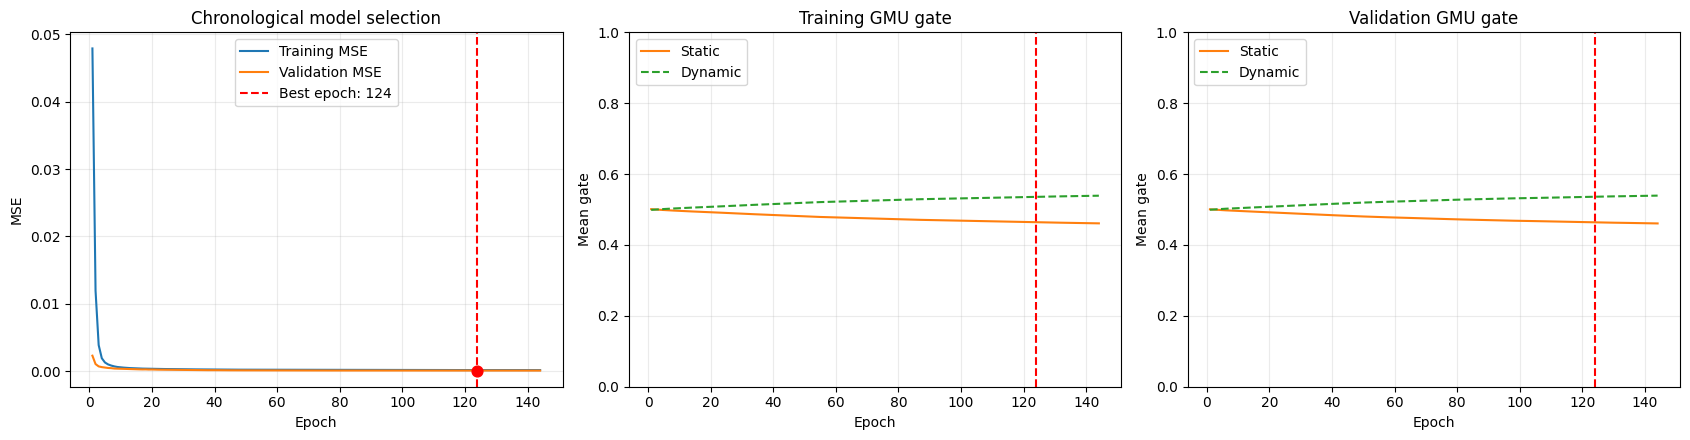

In [29]:
import matplotlib.pyplot as plt
import numpy as np


epochs = np.arange(
    1,
    len(train_loss_history) + 1
)


fig, axes = plt.subplots(
    1,
    3,
    figsize=(17, 4.5)
)


# --------------------------------------------------
# Training and validation losses
# --------------------------------------------------

axes[0].plot(
    epochs,
    train_loss_history,
    color="tab:blue",
    label="Training MSE",
)

axes[0].plot(
    epochs,
    validation_loss_history,
    color="tab:orange",
    label="Validation MSE",
)

axes[0].axvline(
    best_epoch,
    color="red",
    linestyle="--",
    label=f"Best epoch: {best_epoch}",
)

axes[0].scatter(
    best_epoch,
    best_validation_loss,
    color="red",
    s=60,
    zorder=5,
)

axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE")
axes[0].set_title(
    "Chronological model selection"
)
axes[0].legend()
axes[0].grid(alpha=0.25)


# --------------------------------------------------
# Training GMU gate
# --------------------------------------------------

training_static = np.asarray(
    static_gate_history
)

training_dynamic = (
    1.0 - training_static
)


axes[1].plot(
    epochs,
    training_static,
    color="tab:orange",
    label="Static",
)

axes[1].plot(
    epochs,
    training_dynamic,
    color="tab:green",
    linestyle="--",
    label="Dynamic",
)

axes[1].axvline(
    best_epoch,
    color="red",
    linestyle="--",
)

axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Mean gate")
axes[1].set_title(
    "Training GMU gate"
)
axes[1].set_ylim(0, 1)
axes[1].legend()
axes[1].grid(alpha=0.25)


# --------------------------------------------------
# Validation GMU gate
# --------------------------------------------------

validation_static = np.asarray(
    validation_static_gate_history
)

validation_dynamic = (
    1.0 - validation_static
)


axes[2].plot(
    epochs,
    validation_static,
    color="tab:orange",
    label="Static",
)

axes[2].plot(
    epochs,
    validation_dynamic,
    color="tab:green",
    linestyle="--",
    label="Dynamic",
)

axes[2].axvline(
    best_epoch,
    color="red",
    linestyle="--",
)

axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("Mean gate")
axes[2].set_title(
    "Validation GMU gate"
)
axes[2].set_ylim(0, 1)
axes[2].legend()
axes[2].grid(alpha=0.25)


plt.tight_layout()


# Save only if output_folder exists in your notebook.
if "output_folder" in globals():

    plt.savefig(
        os.path.join(
            output_folder,
            "original_gmu_chronological_training.png",
        ),
        dpi=300,
        bbox_inches="tight",
    )


plt.show()

# Training and gate-history plots


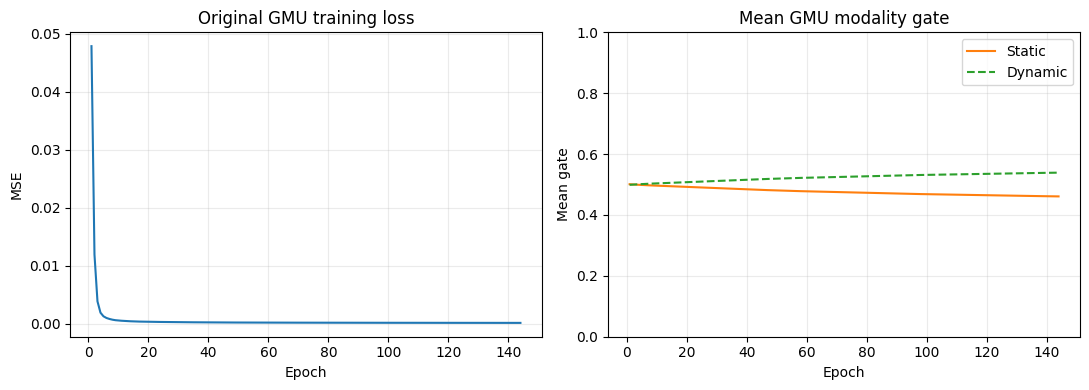

In [30]:
epochs = np.arange(1, len(train_loss_history) + 1)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(epochs, train_loss_history, color="tab:blue")
axes[0].set(title="Original GMU training loss", xlabel="Epoch", ylabel="MSE")
axes[0].grid(alpha=0.25)

axes[1].plot(epochs, static_gate_history, label="Static", color="tab:orange")
axes[1].plot(
    epochs, 1.0 - np.asarray(static_gate_history),
    label="Dynamic", color="tab:green", linestyle="--"
)
axes[1].set(title="Mean GMU modality gate", xlabel="Epoch", ylabel="Mean gate", ylim=(0, 1))
axes[1].legend()
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.savefig(os.path.join(output_folder, "gmu_training_and_gate_history.png"), dpi=300, bbox_inches="tight")
plt.show()


# Test evaluation and collection


In [31]:
@torch.no_grad()
def evaluate_and_collect_gmu(model, loader, device, ablation=None):
    model.eval()
    predictions_per_time = []
    targets_per_time = []
    embeddings_per_time = []
    gates_per_time = []
    node_ids_per_time = []
    time_ids_per_time = []

    for step, data in enumerate(loader):
        data = _move_batch(data, device)
        x_static = data.x_static
        x_dynamic = data.x_dynamic

        if ablation == "static_only":
            x_dynamic = torch.zeros_like(x_dynamic)
        elif ablation == "dynamic_only":
            x_static = torch.zeros_like(x_static)

        prediction, embedding, details = model(
            x_static, x_dynamic, data.edge_index, return_details=True
        )
        target = data.y.float().view_as(prediction)

        n = target.numel()
        node_ids = getattr(data, "node_ids", torch.arange(n, device=device)).reshape(-1)
        time_ids = getattr(data, "time_id", torch.tensor(step, device=device)).reshape(-1)
        if node_ids.numel() == 1 and n > 1:
            node_ids = node_ids.repeat(n)
        if time_ids.numel() == 1 and n > 1:
            time_ids = time_ids.repeat(n)

        predictions_per_time.append(prediction.detach().cpu().numpy())
        targets_per_time.append(target.detach().cpu().numpy())
        embeddings_per_time.append(embedding.detach().cpu())
        gates_per_time.append(details["gate"].detach().cpu())
        node_ids_per_time.append(node_ids.detach().cpu())
        time_ids_per_time.append(time_ids.detach().cpu())

    y_pred = np.concatenate(predictions_per_time)
    y_true = np.concatenate(targets_per_time)
    error = y_pred - y_true
    mse = float(np.mean(error ** 2))
    mae = float(np.mean(np.abs(error)))
    variance = float(np.sum((y_true - y_true.mean()) ** 2))
    r2 = float(1.0 - np.sum(error ** 2) / variance) if variance > 0 else float("nan")

    metrics = {
        "MSE": mse,
        "RMSE": float(np.sqrt(mse)),
        "MAE": mae,
        "R2": r2,
    }
    details = {
        "predictions_per_time": predictions_per_time,
        "targets_per_time": targets_per_time,
        "embeddings_per_time": embeddings_per_time,
        "gates_per_time": gates_per_time,
        "gates": torch.cat(gates_per_time, dim=0),
        "node_ids": torch.cat(node_ids_per_time),
        "time_ids": torch.cat(time_ids_per_time),
    }
    return metrics, details


metrics, test_results = evaluate_and_collect_gmu(model, test_loader, device)
preds_per_t = test_results["predictions_per_time"]
targets_per_t = test_results["targets_per_time"]

display(pd.DataFrame([metrics]))
pd.DataFrame(list(metrics.items()), columns=["Metric", "Value"]).to_csv(
    os.path.join(output_folder, "metrics_GMU_GNN.csv"), index=False
)


,MSE,RMSE,MAE,R2
0,0.000058,0.007587,0.003611,0.980158


# GMU modality contribution

The GMU has a feature-wise gate. For summaries, the gate is averaged over the
hidden dimensions. These values describe the model's learned mixing mechanism;
they are not causal importance scores.


Global mean static gate : 0.4636
Global mean dynamic gate: 0.5364


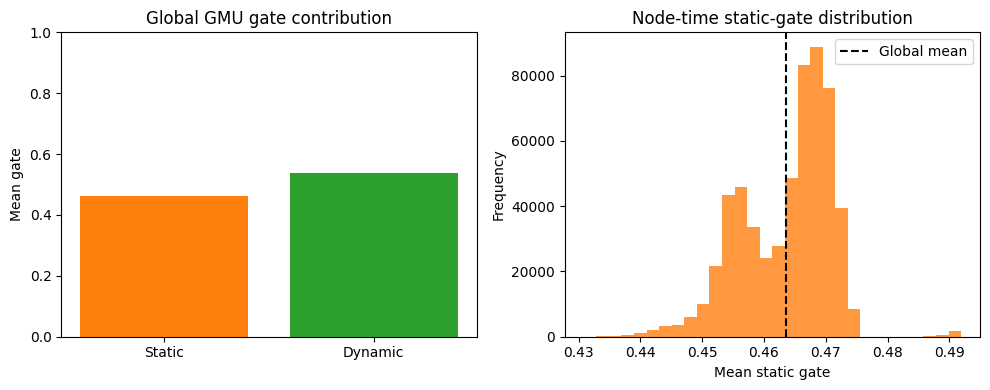

In [32]:
gates = test_results["gates"]                         # [all node-time cases, hidden_dim]
case_static_gate = gates.mean(dim=1)                 # scalar summary per node-time case
global_static_gate = case_static_gate.mean().item()
global_dynamic_gate = 1.0 - global_static_gate

print(f"Global mean static gate : {global_static_gate:.4f}")
print(f"Global mean dynamic gate: {global_dynamic_gate:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].bar(["Static", "Dynamic"], [global_static_gate, global_dynamic_gate],
            color=["tab:orange", "tab:green"])
axes[0].set(title="Global GMU gate contribution", ylabel="Mean gate", ylim=(0, 1))

axes[1].hist(case_static_gate.numpy(), bins=30, color="tab:orange", alpha=0.8)
axes[1].axvline(global_static_gate, color="black", linestyle="--", label="Global mean")
axes[1].set(title="Node-time static-gate distribution", xlabel="Mean static gate", ylabel="Frequency")
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(output_folder, "gmu_global_gate_analysis.png"), dpi=300, bbox_inches="tight")
plt.show()


# Spatial and temporal gate analysis


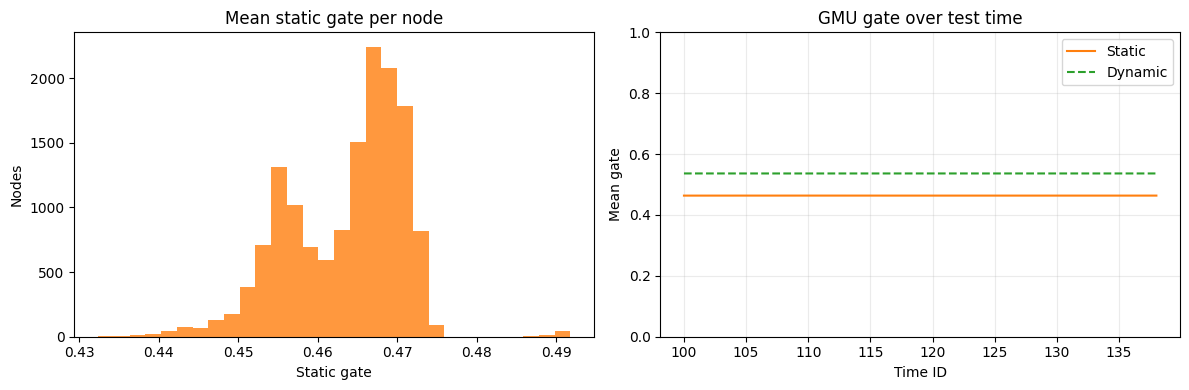

In [33]:
gate_frame = pd.DataFrame({
    "node_id": test_results["node_ids"].numpy(),
    "time_id": test_results["time_ids"].numpy(),
    "static_gate": case_static_gate.numpy(),
})
gate_frame["dynamic_gate"] = 1.0 - gate_frame["static_gate"]

node_gate = gate_frame.groupby("node_id", as_index=False)[["static_gate", "dynamic_gate"]].mean()
time_gate = gate_frame.groupby("time_id", as_index=False)[["static_gate", "dynamic_gate"]].mean()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(node_gate["static_gate"], bins=30, color="tab:orange", alpha=0.8)
axes[0].set(title="Mean static gate per node", xlabel="Static gate", ylabel="Nodes")

axes[1].plot(time_gate["time_id"], time_gate["static_gate"], label="Static", color="tab:orange")
axes[1].plot(time_gate["time_id"], time_gate["dynamic_gate"], label="Dynamic", color="tab:green", linestyle="--")
axes[1].set(title="GMU gate over test time", xlabel="Time ID", ylabel="Mean gate", ylim=(0, 1))
axes[1].legend()
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.savefig(os.path.join(output_folder, "gmu_spatial_temporal_gate_analysis.png"), dpi=300, bbox_inches="tight")
plt.show()

gate_frame.to_csv(os.path.join(output_folder, "gmu_gate_node_time_values.csv"), index=False)


# Representative dynamic-, balanced-, and static-heavy nodes


{'Dynamic-heavy': 4660, 'Balanced': 12949, 'Static-heavy': 12949}


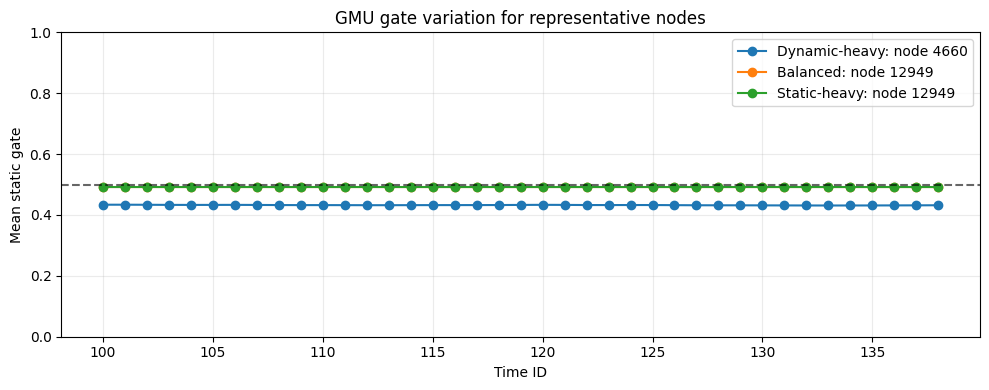

In [34]:
node_gate_sorted = node_gate.sort_values("static_gate").reset_index(drop=True)
dynamic_heavy_node = int(node_gate_sorted.iloc[0]["node_id"])
balanced_node = int(node_gate_sorted.iloc[(node_gate_sorted["static_gate"] - 0.5).abs().argmin()]["node_id"])
static_heavy_node = int(node_gate_sorted.iloc[-1]["node_id"])

selected_nodes = {
    "Dynamic-heavy": dynamic_heavy_node,
    "Balanced": balanced_node,
    "Static-heavy": static_heavy_node,
}
print(selected_nodes)

plt.figure(figsize=(10, 4))
for label, node in selected_nodes.items():
    series = gate_frame[gate_frame["node_id"] == node].sort_values("time_id")
    plt.plot(series["time_id"], series["static_gate"], marker="o", label=f"{label}: node {node}")
plt.axhline(0.5, color="black", linestyle="--", alpha=0.6)
plt.xlabel("Time ID")
plt.ylabel("Mean static gate")
plt.title("GMU gate variation for representative nodes")
plt.ylim(0, 1)
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(os.path.join(output_folder, "gmu_representative_node_gates.png"), dpi=300, bbox_inches="tight")
plt.show()


# Modality ablation

`Static only` zeros the dynamic input, while `Dynamic only` zeros the static
input. The already-trained full model is not retrained; this measures input
ablation sensitivity. For a stronger paper experiment, also train separate
static-only and dynamic-only models from scratch.


,Input,MSE,RMSE,MAE,R2
0,Full GMU,0.000058,0.007587,0.003611,0.980158
1,Static only,0.003624,0.060199,0.028151,-0.249099
2,Dynamic only,0.000126,0.011242,0.005022,0.956439


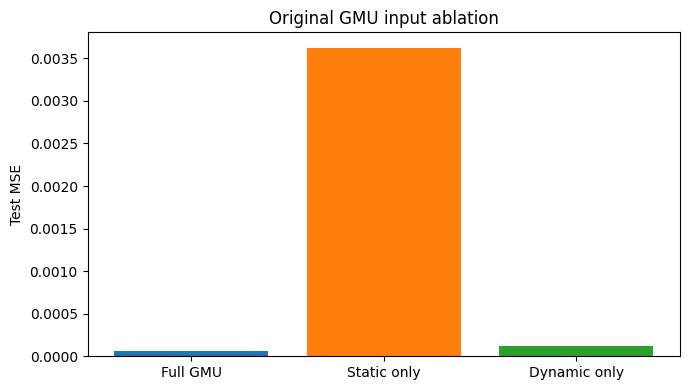

In [35]:
static_metrics, _ = evaluate_and_collect_gmu(model, test_loader, device, ablation="static_only")
dynamic_metrics, _ = evaluate_and_collect_gmu(model, test_loader, device, ablation="dynamic_only")

ablation_results = pd.DataFrame([
    {"Input": "Full GMU", **metrics},
    {"Input": "Static only", **static_metrics},
    {"Input": "Dynamic only", **dynamic_metrics},
])
display(ablation_results)
ablation_results.to_csv(os.path.join(output_folder, "gmu_ablation_results.csv"), index=False)

plt.figure(figsize=(7, 4))
plt.bar(ablation_results["Input"], ablation_results["MSE"],
        color=["tab:blue", "tab:orange", "tab:green"])
plt.ylabel("Test MSE")
plt.title("Original GMU input ablation")
plt.tight_layout()
plt.savefig(os.path.join(output_folder, "gmu_ablation_mse.png"), dpi=300, bbox_inches="tight")
plt.show()


# Gradient sensitivity check


In [36]:
def gradient_sensitivity(model, data, device):
    model.eval()
    data = data.to(device)
    x_static = data.x_static.detach().clone().requires_grad_(True)
    x_dynamic = data.x_dynamic.detach().clone().requires_grad_(True)
    prediction, _ = model(x_static, x_dynamic, data.edge_index)
    prediction.mean().backward()
    return {
        "Static mean |gradient|": x_static.grad.abs().mean().item(),
        "Dynamic mean |gradient|": x_dynamic.grad.abs().mean().item(),
    }


gradient_results = gradient_sensitivity(model, next(iter(test_loader)), device)
display(pd.DataFrame([gradient_results]))


,Static mean |gradient|,Dynamic mean |gradient|
0,6.444295e-07,0.000012


# Predicted time-series and neighborhood analysis


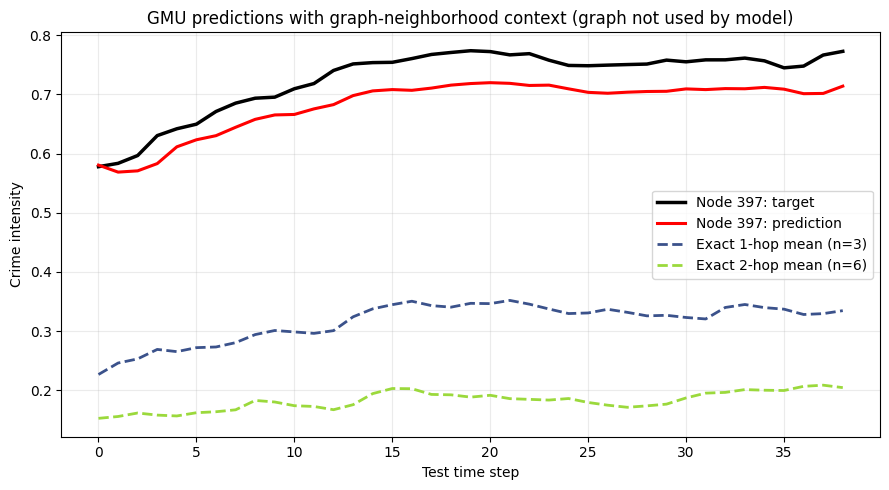

In [37]:
def adjacency_from_edge_index(edge_index, num_nodes):
    adjacency = {i: set() for i in range(num_nodes)}
    src, dst = edge_index.detach().cpu().numpy()
    for u, v in zip(src, dst):
        adjacency[int(u)].add(int(v))
        adjacency[int(v)].add(int(u))
    return adjacency


def exact_hop_nodes(center, adjacency, hop):
    visited = {center}
    frontier = {center}
    for _ in range(hop):
        next_frontier = set()
        for node in frontier:
            next_frontier.update(adjacency.get(node, set()))
        next_frontier -= visited
        visited |= next_frontier
        frontier = next_frontier
    return sorted(frontier)


def plot_neighborhood_prediction(pred_matrix, target_matrix, center_node, adjacency,
                                 max_hop=2, output_path=None):
    time = np.arange(pred_matrix.shape[0])
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.plot(time, target_matrix[:, center_node], color="black", linewidth=2.5,
            label=f"Node {center_node}: target")
    ax.plot(time, pred_matrix[:, center_node], color="red", linewidth=2.2,
            label=f"Node {center_node}: prediction")

    colors = plt.cm.viridis(np.linspace(0.25, 0.85, max_hop))
    for hop, color in zip(range(1, max_hop + 1), colors):
        nodes = exact_hop_nodes(center_node, adjacency, hop)
        if nodes:
            mean_series = pred_matrix[:, nodes].mean(axis=1)
            ax.plot(time, mean_series, linestyle="--", linewidth=2, color=color,
                    label=f"Exact {hop}-hop mean (n={len(nodes)})")

    ax.set(xlabel="Test time step", ylabel="Crime intensity",
           title="GMU predictions with graph-neighborhood context (graph not used by model)")
    ax.legend()
    ax.grid(alpha=0.25)
    fig.tight_layout()
    if output_path:
        fig.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()


pred_matrix = np.stack(preds_per_t)
target_matrix = np.stack(targets_per_t)
sample_graph = test_dataset[0]
adjacency = adjacency_from_edge_index(sample_graph.edge_index, pred_matrix.shape[1])

# Select the node with the highest mean target crime in the test period.
selected_node = int(np.argmax(target_matrix.mean(axis=0)))
plot_neighborhood_prediction(
    pred_matrix, target_matrix, selected_node, adjacency, max_hop=2,
    output_path=os.path.join(output_folder, "gmu_high_crime_node_neighborhood.png")
)


# Prediction scatter and residual analysis


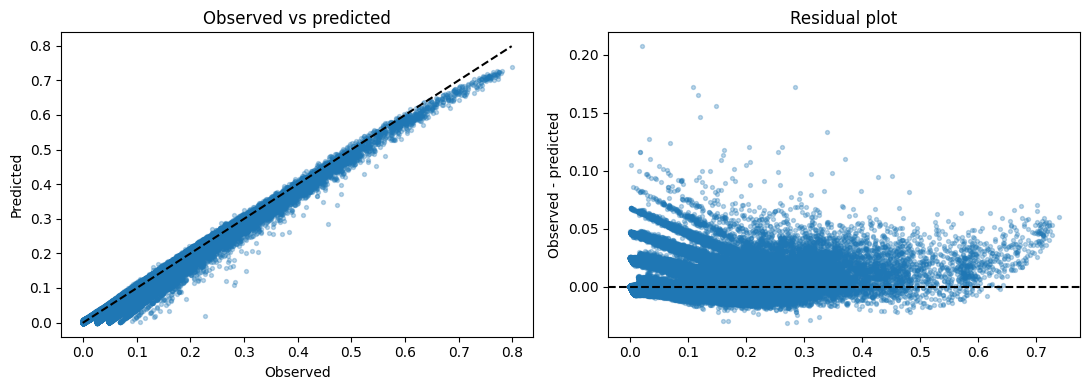

In [38]:
y_true = target_matrix.reshape(-1)
y_pred = pred_matrix.reshape(-1)
residual = y_true - y_pred

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].scatter(y_true, y_pred, s=8, alpha=0.3)
lo = min(y_true.min(), y_pred.min())
hi = max(y_true.max(), y_pred.max())
axes[0].plot([lo, hi], [lo, hi], color="black", linestyle="--")
axes[0].set(title="Observed vs predicted", xlabel="Observed", ylabel="Predicted")

axes[1].scatter(y_pred, residual, s=8, alpha=0.3)
axes[1].axhline(0, color="black", linestyle="--")
axes[1].set(title="Residual plot", xlabel="Predicted", ylabel="Observed - predicted")

plt.tight_layout()
plt.savefig(os.path.join(output_folder, "gmu_prediction_diagnostics.png"), dpi=300, bbox_inches="tight")
plt.show()


# Explainability

In [39]:
import numpy as np
import pandas as pd
import torch


def _expand_metadata(value, number_of_nodes, device):
    """
    Convert scalar node/time metadata into one value per node.
    """
    if value is None:
        return None

    value = value.reshape(-1)

    if value.numel() == 1 and number_of_nodes > 1:
        value = value.repeat(number_of_nodes)

    return value


@torch.no_grad()
def collect_gate_explainability(
    model,
    loader,
    device,
    model_type,
):
    """
    Collect gate values and crime information.

    Parameters
    ----------
    model:
        Complete trained model.

    loader:
        PyG test or training loader.

    device:
        'cpu', 'cuda', or torch.device.

    model_type:
        One of:
        - 'gmu'
        - 'gmu_gnn'
        - 'm11_vector'

    Returns
    -------
    Dictionary containing node/time IDs, crime intensity,
    target crime, predictions, and gate summaries.
    """

    valid_types = {
        "gmu",
        "gmu_gnn",
        "m11_vector",
    }

    if model_type not in valid_types:
        raise ValueError(
            f"model_type must be one of {valid_types}"
        )

    model.eval()
    device = torch.device(device)

    all_node_ids = []
    all_time_ids = []
    all_input_crime = []
    all_target_crime = []
    all_predictions = []

    # GMU gate
    all_gate_static = []
    all_gate_vectors = []

    # M11 gates
    all_gate_self = []
    all_gate_neigh = []
    all_gate_self_vectors = []
    all_gate_neigh_vectors = []

    for step, data in enumerate(loader):
        data = data.to(device)

        output = model(
            data.x_static,
            data.x_dynamic,
            data.edge_index,
            return_details=True,
        )

        prediction, embedding, details = output
        prediction = prediction.reshape(-1)

        number_of_nodes = prediction.numel()

        # -----------------------------
        # Node IDs
        # -----------------------------
        node_ids = getattr(
            data,
            "node_ids",
            torch.arange(
                number_of_nodes,
                device=device,
            ),
        )

        node_ids = _expand_metadata(
            node_ids,
            number_of_nodes,
            device,
        )

        # -----------------------------
        # Time IDs
        # -----------------------------
        time_ids = getattr(
            data,
            "time_id",
            torch.tensor(
                step,
                device=device,
            ),
        )

        time_ids = _expand_metadata(
            time_ids,
            number_of_nodes,
            device,
        )

        # Average observed crime in the input window
        input_crime = data.x_dynamic.mean(dim=1)

        # Next-period target
        target_crime = data.y.float().reshape(-1)

        all_node_ids.append(
            node_ids.detach().cpu()
        )
        all_time_ids.append(
            time_ids.detach().cpu()
        )
        all_input_crime.append(
            input_crime.detach().cpu()
        )
        all_target_crime.append(
            target_crime.detach().cpu()
        )
        all_predictions.append(
            prediction.detach().cpu()
        )

        # =============================
        # GMU and GMU-GNN
        # =============================
        if model_type in {"gmu", "gmu_gnn"}:
            gate_vector = details["gate"]

            if gate_vector.ndim == 1:
                gate_vector = gate_vector.unsqueeze(-1)

            # Average across hidden dimensions
            gate_static = gate_vector.mean(dim=-1)

            all_gate_static.append(
                gate_static.detach().cpu()
            )
            all_gate_vectors.append(
                gate_vector.detach().cpu()
            )

        # =============================
        # M11 adaptive vector gates
        # =============================
        elif model_type == "m11_vector":
            gate_self_vector = details["self_gate"]
            gate_neigh_vector = details["neighbor_gate"]

            if gate_self_vector.ndim == 1:
                gate_self_vector = (
                    gate_self_vector.unsqueeze(-1)
                )

            if gate_neigh_vector.ndim == 1:
                gate_neigh_vector = (
                    gate_neigh_vector.unsqueeze(-1)
                )

            gate_self = gate_self_vector.mean(dim=-1)
            gate_neigh = gate_neigh_vector.mean(dim=-1)

            all_gate_self.append(
                gate_self.detach().cpu()
            )
            all_gate_neigh.append(
                gate_neigh.detach().cpu()
            )
            all_gate_self_vectors.append(
                gate_self_vector.detach().cpu()
            )
            all_gate_neigh_vectors.append(
                gate_neigh_vector.detach().cpu()
            )

    results = {
        "node_ids": torch.cat(all_node_ids),
        "time_ids": torch.cat(all_time_ids),
        "input_crime": torch.cat(all_input_crime),
        "target_crime": torch.cat(all_target_crime),
        "predictions": torch.cat(all_predictions),
        "model_type": model_type,
    }

    if model_type in {"gmu", "gmu_gnn"}:
        results.update({
            "gate_static": torch.cat(
                all_gate_static
            ),
            "gate_dynamic": (
                1.0 - torch.cat(all_gate_static)
            ),
            "gate_vectors": torch.cat(
                all_gate_vectors
            ),
        })

    elif model_type == "m11_vector":
        gate_self = torch.cat(all_gate_self)
        gate_neigh = torch.cat(all_gate_neigh)

        results.update({
            "gate_self": gate_self,
            "gate_neigh": gate_neigh,
            "gate_self_dynamic": 1.0 - gate_self,
            "gate_neigh_dynamic": 1.0 - gate_neigh,
            "gate_self_vectors": torch.cat(
                all_gate_self_vectors
            ),
            "gate_neigh_vectors": torch.cat(
                all_gate_neigh_vectors
            ),
        })

    return results

In [40]:
results = collect_gate_explainability(
    model=model,
    loader=test_loader,
    device=device,
    model_type="gmu",
)

In [41]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr


def analyze_gate_vs_crime(
    results,
    gate_key,
    crime_key="input_crime",
    gate_label=None,
    filename="gate_vs_crime",
    output_path=None,
):
    """
    Analyze association between a gate summary and crime.

    gate_key examples:
        GMU:
            'gate_static'

        M11:
            'gate_self'
            'gate_neigh'

    crime_key:
        'input_crime'  -> mean crime in input window
        'target_crime' -> next-period target crime
    """

    gate = results[gate_key].detach().cpu().numpy()
    crime = results[crime_key].detach().cpu().numpy()

    valid = (
        np.isfinite(gate)
        & np.isfinite(crime)
    )

    gate = gate[valid]
    crime = crime[valid]

    if gate.size < 3:
        raise ValueError(
            "At least three valid observations are required."
        )

    if np.std(gate) == 0:
        print(
            f"{gate_key} is constant; correlation "
            "cannot be calculated."
        )
        return None

    pearson_r, pearson_p = pearsonr(
        crime,
        gate,
    )

    spearman_r, spearman_p = spearmanr(
        crime,
        gate,
    )

    if gate_label is None:
        gate_label = gate_key.replace("_", " ").title()

    print(f"Analysis: {gate_label}")
    print(
        f"Pearson r = {pearson_r:.4f}, "
        f"p = {pearson_p:.4e}"
    )
    print(
        f"Spearman ρ = {spearman_r:.4f}, "
        f"p = {spearman_p:.4e}"
    )

    plt.figure(figsize=(7, 5))

    plt.scatter(
        crime,
        gate,
        s=14,
        alpha=0.30,
        color="tab:blue",
        label=(
            f"Pearson r={pearson_r:.2f}; "
            f"Spearman ρ={spearman_r:.2f}"
        ),
    )

    plt.xlabel(
        "Mean input-window crime"
        if crime_key == "input_crime"
        else "Next-period target crime"
    )
    plt.ylabel(gate_label)
    plt.title(f"{gate_label} vs crime intensity")
    plt.ylim(0, 1)
    plt.grid(alpha=0.20)
    plt.legend()
    plt.tight_layout()

    if output_path is not None:
        os.makedirs(
            output_path,
            exist_ok=True,
        )

        plt.savefig(
            os.path.join(
                output_path,
                f"{filename}.png",
            ),
            dpi=300,
            bbox_inches="tight",
        )

    plt.show()
    plt.close()

    return {
        "pearson_r": pearson_r,
        "pearson_p": pearson_p,
        "spearman_r": spearman_r,
        "spearman_p": spearman_p,
    }

Analysis: Mean GMU static gate
Pearson r = -0.3864, p = 0.0000e+00
Spearman ρ = -0.2753, p = 0.0000e+00


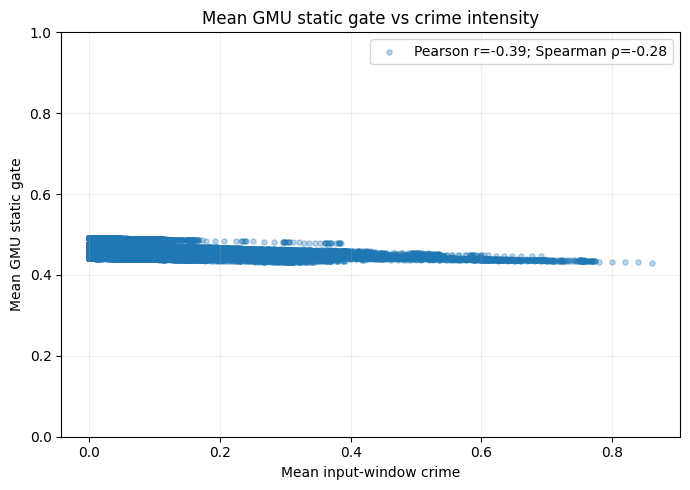

In [42]:
gmu_input_association = analyze_gate_vs_crime(
    results=results,
    gate_key="gate_static",
    crime_key="input_crime",
    gate_label="Mean GMU static gate",
    filename=(
        f"input_crime_vs_static_gate_{model_used}"
    ),
    output_path=output_folder,
)

# Interpretation notes

- A GMU gate near 1 favors the static latent representation; a gate near 0
  favors the dynamic latent representation.
- The gate is feature-wise, so its mean is only a compact summary.
- Gate values are learned mixing coefficients, not causal modality effects.
- The ablation experiment complements the gate analysis but does not replace
  separately trained static-only and dynamic-only baselines.
- For fair comparison with your message-level fusion model, use the same hidden dimension, optimizer policy, epochs, seeds, and evaluation split.
  Graph use must be reported as an architectural difference rather than silently matched.


# Complete GMU explainability and validation suite

This appendix makes the original GMU-only baseline analytically consistent with the
M11 notebook wherever the architectures permit a valid comparison. It does not alter
data preprocessing, dataset construction, training, or the existing analyses.

## Architectural comparability

| M11 analysis | Original GMU equivalent | Eligibility |
|---|---|---|
| Self and neighbor gate health | Single GMU gate health | Applicable with one role |
| Feature-wise gate specialization | GMU feature-wise specialization | Applicable |
| Gate–crime association | GMU gate–crime association | Applicable |
| Effective activation contribution | GMU effective activation contribution | Applicable |
| Self-versus-neighbor separation | None | **Not defined: GMU has one gate and no message passing** |
| Spatial/temporal stability | GMU node/time stability | Applicable |
| Gate–error relationship | GMU gate–error relationship | Applicable |
| Gate intervention | Single-gate interventions | Applicable |
| Input permutation importance | Static/dynamic input permutation | Applicable |
| Time-cluster bootstrap | Single-gate bootstrap | Applicable |
| Neighborhood-message explanation | None | **Not defined: GMU ignores `edge_index`** |

The existing exact-hop plot is retained only as contextual comparison between focal-node
predictions and graph neighbors. It must not be interpreted as learned neighborhood behavior.

### Split audit

The `InductiveWrapperDataset` calls are commented out in the supplied preprocessing.
Consequently, the executed configuration uses a chronological test period but includes the
same nodes in training and testing. It is temporally held out and node-transductive, not a
strict unseen-node inductive experiment. This note documents the current setup without
changing it.

## A. GMU embedding projection

t-SNE is included for parity with M11. It visualizes local structure in the fused GMU
representation from the first test window; it is not a quantitative performance measure.

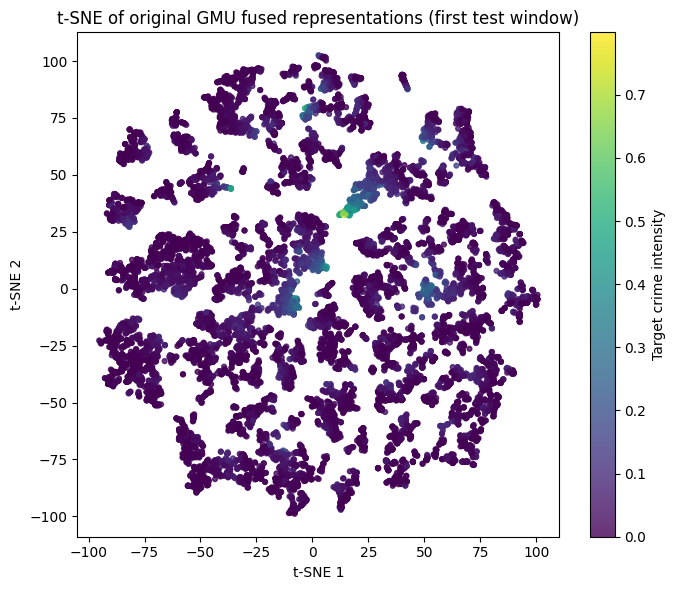

In [43]:
from sklearn.manifold import TSNE

embedding = test_results["embeddings_per_time"][0].numpy()
target_first_window = targets_per_t[0]

if embedding.shape[0] >= 3:
    perplexity = min(30, max(2, (embedding.shape[0] - 1) // 3))
    embedding_2d = TSNE(
        n_components=2,
        perplexity=perplexity,
        init="pca",
        learning_rate="auto",
        random_state=seed,
    ).fit_transform(embedding)
    plt.figure(figsize=(7, 6))
    scatter = plt.scatter(
        embedding_2d[:, 0], embedding_2d[:, 1], c=target_first_window,
        cmap="viridis", s=12, alpha=0.8
    )
    plt.colorbar(scatter, label="Target crime intensity")
    plt.title("t-SNE of original GMU fused representations (first test window)")
    plt.xlabel("t-SNE 1")
    plt.ylabel("t-SNE 2")
    plt.tight_layout()
    plt.savefig(os.path.join(output_folder, "gmu_embedding_tsne.png"), dpi=300, bbox_inches="tight")
    plt.show()
    pd.DataFrame({
        "tsne_1": embedding_2d[:, 0], "tsne_2": embedding_2d[:, 1],
        "target_crime": target_first_window,
    }).to_csv(os.path.join(output_folder, "gmu_embedding_tsne.csv"), index=False)
else:
    print("At least three nodes are required for t-SNE.")

## B. Rich node-time GMU explainability collection

This cell collects the exact feature-wise GMU gate, both `tanh` modality candidates,
their gated activation magnitudes, predictions, errors, node IDs and time IDs. The same
definitions are then reused by all remaining analyses.

In [44]:
import contextlib
import math
import warnings

try:
    from scipy.stats import pearsonr, spearmanr
    SCIPY_AVAILABLE = True
except ImportError:
    SCIPY_AVAILABLE = False
    warnings.warn("SciPy is unavailable; p-values will be skipped.")


def _expand_gmu_metadata(value, n, fallback, device):
    if value is None:
        value = torch.as_tensor(fallback, device=device)
    value = value.reshape(-1)
    if value.numel() == 1 and n > 1:
        value = value.repeat(n)
    if value.numel() != n:
        raise ValueError(f"Metadata length {value.numel()} does not match node count {n}.")
    return value


@torch.no_grad()
def collect_rich_gmu_explainability(model, loader, device):
    model.eval()
    frames, gate_vectors = [], []
    for step, data in enumerate(loader):
        data = data.to(device)
        prediction, embedding, details = model(
            data.x_static, data.x_dynamic, data.edge_index, return_details=True
        )
        prediction = prediction.reshape(-1)
        target = data.y.float().view_as(prediction)
        n = prediction.numel()
        node_ids = _expand_gmu_metadata(
            getattr(data, "node_ids", None), n, torch.arange(n, device=device), device
        )
        time_ids = _expand_gmu_metadata(getattr(data, "time_id", None), n, step, device)

        gate = details["gate"]
        h_static = details["h_static"]
        h_dynamic = details["h_dynamic"]
        static_component = gate * h_static
        dynamic_component = (1.0 - gate) * h_dynamic
        static_mag = torch.linalg.vector_norm(static_component, dim=1)
        dynamic_mag = torch.linalg.vector_norm(dynamic_component, dim=1)
        static_prop = static_mag / (static_mag + dynamic_mag + 1e-12)

        frames.append(pd.DataFrame({
            "node_id": node_ids.cpu().numpy(),
            "time_id": time_ids.cpu().numpy(),
            "input_crime": data.x_dynamic.mean(dim=1).cpu().numpy(),
            "target_crime": target.cpu().numpy(),
            "prediction": prediction.cpu().numpy(),
            "residual": (target - prediction).cpu().numpy(),
            "absolute_error": (target - prediction).abs().cpu().numpy(),
            "gmu_static_gate": gate.mean(dim=1).cpu().numpy(),
            "gmu_dynamic_gate": (1.0 - gate).mean(dim=1).cpu().numpy(),
            "static_activation": static_mag.cpu().numpy(),
            "dynamic_activation": dynamic_mag.cpu().numpy(),
            "static_activation_proportion": static_prop.cpu().numpy(),
            "dynamic_activation_proportion": (1.0-static_prop).cpu().numpy(),
        }))
        gate_vectors.append(gate.cpu())
    return pd.concat(frames, ignore_index=True), torch.cat(gate_vectors).numpy()


gmu_explain_frame, gmu_gate_vectors = collect_rich_gmu_explainability(
    model, test_loader, device
)
print("Explainability cases:", len(gmu_explain_frame))
print("GMU gate vector shape:", gmu_gate_vectors.shape)
display(gmu_explain_frame.head())
gmu_explain_frame.to_csv(os.path.join(output_folder, "gmu_rich_explainability_cases.csv"), index=False)

Explainability cases: 570960
GMU gate vector shape: (570960, 64)


,node_id,time_id,input_crime,target_crime,prediction,residual,absolute_error,gmu_static_gate,gmu_dynamic_gate,static_activation,dynamic_activation,static_activation_proportion,dynamic_activation_proportion
0,0,100,0.126909,0.136371,0.107113,0.029258,0.029258,0.458440,0.541560,1.208764,0.275899,0.814167,0.185833
1,1,100,0.109170,0.097192,0.102752,-0.005560,0.005560,0.467166,0.532834,1.136963,0.237129,0.827429,0.172571
2,2,100,0.161374,0.125887,0.131925,-0.006038,0.006038,0.458711,0.541289,1.176003,0.332807,0.779424,0.220576
3,3,100,0.096176,0.097884,0.086527,0.011357,0.011357,0.462037,0.537963,1.115636,0.221559,0.834311,0.165689
4,4,100,0.014133,0.041428,0.043426,-0.001997,0.001997,0.464118,0.535882,1.172520,0.112391,0.912530,0.087470


## C. Gate health: variation, entropy and saturation

A global mean near 0.5 is not gate collapse. Collapse is better assessed through
feature-wise variance, case-level variance, entropy, saturation, intervention evidence,
and repeatability across seeds.

,role,global_mean,global_std,case_mean_std,q05,median,q95,minimum,maximum,mean_entropy_0_to_1,fraction_below_0.10,fraction_above_0.90,fraction_near_balanced_0.45_0.55
0,single_GMU_gate,0.4636,0.0856,0.0073,0.3229,0.4683,0.5955,0.0636,0.7942,0.9743,0.0,0.0,0.4419


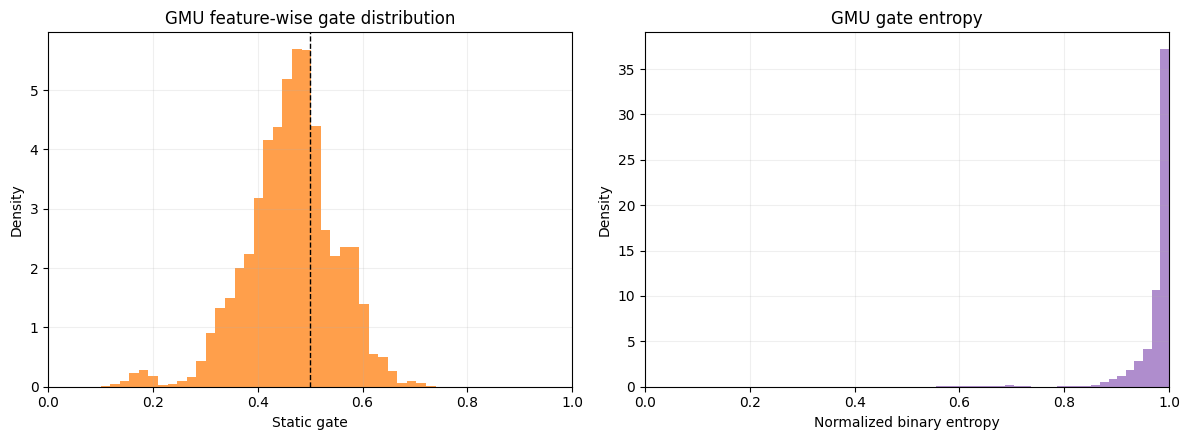

In [45]:
def binary_gate_entropy(gates, eps=1e-8):
    g = np.clip(np.asarray(gates), eps, 1.0-eps)
    return -(g*np.log(g) + (1.0-g)*np.log(1.0-g)) / np.log(2.0)


flat_gate = gmu_gate_vectors.reshape(-1)
case_gate = gmu_gate_vectors.mean(axis=1)
gmu_gate_health = pd.DataFrame([{
    "role": "single_GMU_gate",
    "global_mean": flat_gate.mean(),
    "global_std": flat_gate.std(),
    "case_mean_std": case_gate.std(),
    "q05": np.quantile(flat_gate, 0.05),
    "median": np.median(flat_gate),
    "q95": np.quantile(flat_gate, 0.95),
    "minimum": flat_gate.min(),
    "maximum": flat_gate.max(),
    "mean_entropy_0_to_1": binary_gate_entropy(flat_gate).mean(),
    "fraction_below_0.10": np.mean(flat_gate < 0.10),
    "fraction_above_0.90": np.mean(flat_gate > 0.90),
    "fraction_near_balanced_0.45_0.55": np.mean((flat_gate >= 0.45) & (flat_gate <= 0.55)),
}])
display(gmu_gate_health.round(4))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].hist(flat_gate, bins=40, density=True, alpha=0.75, color="tab:orange")
axes[0].axvline(0.5, color="black", linestyle="--", linewidth=1)
axes[0].set(title="GMU feature-wise gate distribution", xlabel="Static gate", ylabel="Density", xlim=(0, 1))
axes[1].hist(binary_gate_entropy(flat_gate), bins=40, density=True, alpha=0.75, color="tab:purple")
axes[1].set(title="GMU gate entropy", xlabel="Normalized binary entropy", ylabel="Density", xlim=(0, 1))
for ax in axes:
    ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig(os.path.join(output_folder, "gmu_professional_gate_health.png"), dpi=300, bbox_inches="tight")
plt.show()
gmu_gate_health.to_csv(os.path.join(output_folder, "gmu_professional_gate_health.csv"), index=False)

## D. Feature-wise GMU specialization

GMU has an $N\times H$ gate. This analysis checks whether averaging across the 64 latent
dimensions hides opposing static- and dynamic-preferring components.

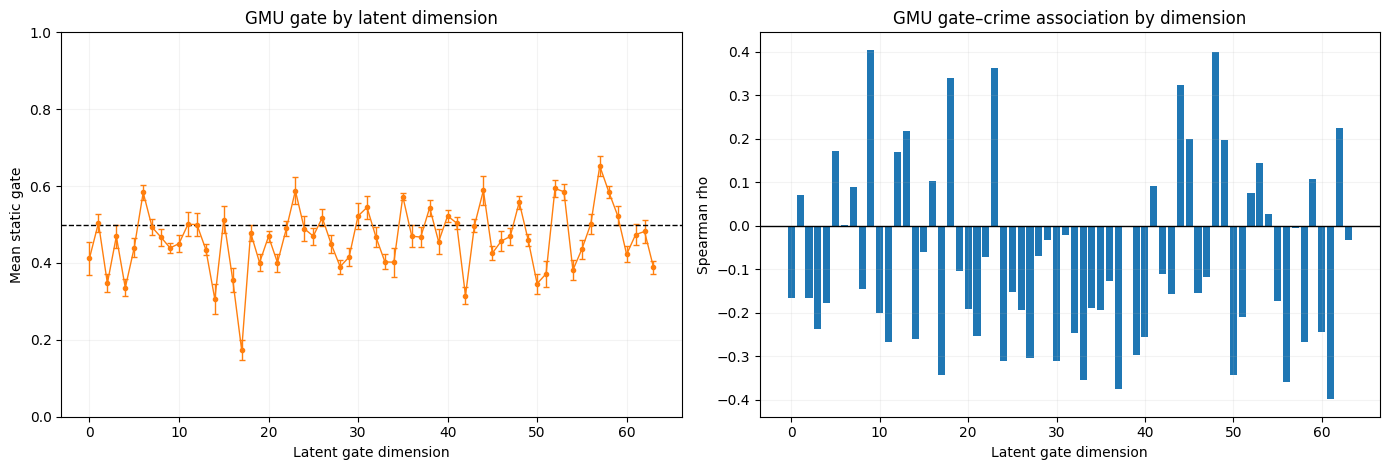

,dimension,mean_gate,std_gate,crime_spearman_rho,crime_spearman_p
9,9,0.439097,0.014088,0.404100,0.0
61,61,0.473731,0.027626,-0.399405,0.0
48,48,0.558165,0.016971,0.399091,0.0
37,37,0.467356,0.025267,-0.374945,0.0
23,23,0.587937,0.035321,0.363350,0.0
56,56,0.501651,0.025228,-0.360135,0.0
33,33,0.402847,0.019372,-0.356269,0.0
50,50,0.346126,0.025958,-0.344554,0.0
17,17,0.173458,0.026350,-0.344205,0.0
18,18,0.478883,0.020637,0.340285,0.0


In [46]:
def safe_correlations(x, matrix, method="spearman"):
    x = np.asarray(x)
    values, pvalues = [], []
    for k in range(matrix.shape[1]):
        y = matrix[:, k]
        if np.std(x) == 0 or np.std(y) == 0:
            values.append(np.nan); pvalues.append(np.nan)
        elif SCIPY_AVAILABLE:
            result = spearmanr(x, y) if method == "spearman" else pearsonr(x, y)
            values.append(float(result[0])); pvalues.append(float(result[1]))
        else:
            values.append(float(np.corrcoef(x, y)[0, 1])); pvalues.append(np.nan)
    return np.asarray(values), np.asarray(pvalues)


crime_values = gmu_explain_frame["input_crime"].to_numpy()
gate_means = gmu_gate_vectors.mean(axis=0)
gate_stds = gmu_gate_vectors.std(axis=0)
gate_rho, gate_p = safe_correlations(crime_values, gmu_gate_vectors, "spearman")
dims = np.arange(gmu_gate_vectors.shape[1])

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
axes[0].errorbar(dims, gate_means, yerr=gate_stds, marker="o", markersize=3,
                 linewidth=1, capsize=2, color="tab:orange")
axes[0].axhline(0.5, color="black", linestyle="--", linewidth=1)
axes[0].set(title="GMU gate by latent dimension", xlabel="Latent gate dimension",
            ylabel="Mean static gate", ylim=(0, 1))
axes[1].bar(dims, gate_rho, color="tab:blue")
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set(title="GMU gate–crime association by dimension", xlabel="Latent gate dimension",
            ylabel="Spearman rho")
for ax in axes: ax.grid(alpha=0.15)
plt.tight_layout()
plt.savefig(os.path.join(output_folder, "gmu_featurewise_gate_specialization.png"), dpi=300, bbox_inches="tight")
plt.show()

gmu_featurewise_gate_stats = pd.DataFrame({
    "dimension": dims, "mean_gate": gate_means, "std_gate": gate_stds,
    "crime_spearman_rho": gate_rho, "crime_spearman_p": gate_p,
})
display(gmu_featurewise_gate_stats.reindex(
    gmu_featurewise_gate_stats.crime_spearman_rho.abs().sort_values(ascending=False).index
).head(10))
gmu_featurewise_gate_stats.to_csv(os.path.join(output_folder, "gmu_featurewise_gate_stats.csv"), index=False)

## E. GMU gate association with input and future crime

Pearson measures linear association and Spearman measures monotonic association. Statistics
use all original node-time cases; quantile bins are used only to make the plot readable.

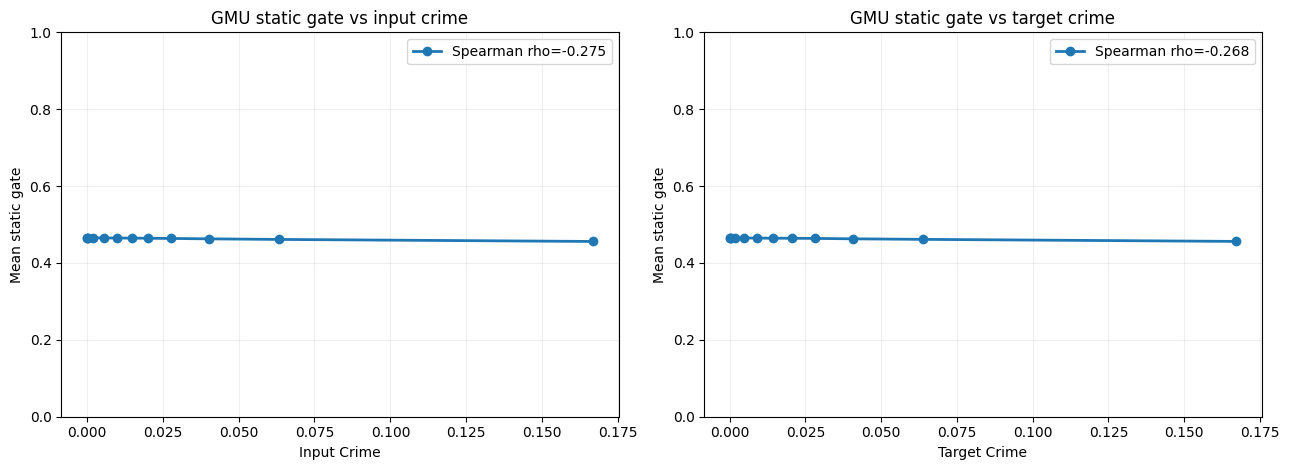

,role,crime_variable,pearson_r,pearson_p,spearman_rho,spearman_p
0,GMU,input_crime,-0.38638,0.0,-0.27526,0.0
1,GMU,target_crime,-0.37933,0.0,-0.26754,0.0


In [47]:
def association_stats(x, y):
    x, y = np.asarray(x), np.asarray(y)
    valid = np.isfinite(x) & np.isfinite(y)
    x, y = x[valid], y[valid]
    if len(x) < 3 or np.std(x) == 0 or np.std(y) == 0:
        return {"pearson_r": np.nan, "pearson_p": np.nan,
                "spearman_rho": np.nan, "spearman_p": np.nan}
    if SCIPY_AVAILABLE:
        pr, sr = pearsonr(x, y), spearmanr(x, y)
        return {"pearson_r": float(pr[0]), "pearson_p": float(pr[1]),
                "spearman_rho": float(sr[0]), "spearman_p": float(sr[1])}
    return {"pearson_r": float(np.corrcoef(x, y)[0, 1]), "pearson_p": np.nan,
            "spearman_rho": np.nan, "spearman_p": np.nan}


def binned_summary(frame, x_col, y_col, bins=12):
    work = frame[[x_col, y_col]].replace([np.inf, -np.inf], np.nan).dropna().copy()
    work["bin"] = pd.qcut(work[x_col], q=bins, duplicates="drop")
    out = work.groupby("bin", observed=True).agg(
        mean_x=(x_col, "mean"), mean_y=(y_col, "mean"),
        std_y=(y_col, "std"), count=(y_col, "size")
    ).reset_index(drop=True)
    out["ci95"] = 1.96*out["std_y"] / np.sqrt(out["count"].clip(lower=1))
    return out


gmu_association_rows = []
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
for ax, x_col in zip(axes, ["input_crime", "target_crime"]):
    stats = association_stats(gmu_explain_frame[x_col], gmu_explain_frame["gmu_static_gate"])
    gmu_association_rows.append({"role": "GMU", "crime_variable": x_col, **stats})
    summary = binned_summary(gmu_explain_frame, x_col, "gmu_static_gate", bins=12)
    ax.plot(summary["mean_x"], summary["mean_y"], marker="o", linewidth=2)
    ax.fill_between(summary["mean_x"], summary["mean_y"]-summary["ci95"],
                    summary["mean_y"]+summary["ci95"], alpha=0.2)
    ax.set(title=f"GMU static gate vs {x_col.replace('_', ' ')}",
           xlabel=x_col.replace("_", " ").title(), ylabel="Mean static gate", ylim=(0, 1))
    ax.legend([f"Spearman rho={stats['spearman_rho']:.3f}"])
    ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig(os.path.join(output_folder, "gmu_gate_crime_associations.png"), dpi=300, bbox_inches="tight")
plt.show()
gmu_gate_crime_associations = pd.DataFrame(gmu_association_rows)
display(gmu_gate_crime_associations.round(5))
gmu_gate_crime_associations.to_csv(os.path.join(output_folder, "gmu_gate_crime_associations.csv"), index=False)

## F. Effective gated activation contribution

Raw gates do not include the magnitude of `tanh` candidate representations. The effective
static proportion below compares $\|z\odot h_s\|_2$ with
$\|(1-z)\odot h_d\|_2$. It is a representation-magnitude diagnostic, not causal importance.

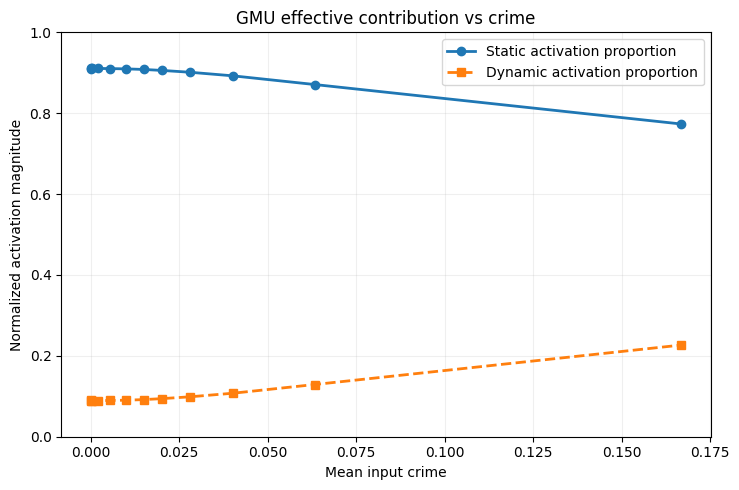

,role,mean_raw_static_gate,mean_effective_static_proportion,mean_effective_dynamic_proportion,gate_vs_effective_pearson
0,single_GMU_gate,0.4636,0.8929,0.1071,0.15


In [48]:
summary = binned_summary(gmu_explain_frame, "input_crime", "static_activation_proportion", bins=12)
plt.figure(figsize=(7.5, 5))
plt.plot(summary["mean_x"], summary["mean_y"], marker="o", linewidth=2,
         label="Static activation proportion")
plt.plot(summary["mean_x"], 1.0-summary["mean_y"], marker="s", linestyle="--",
         linewidth=2, label="Dynamic activation proportion")
plt.fill_between(summary["mean_x"], summary["mean_y"]-summary["ci95"],
                 summary["mean_y"]+summary["ci95"], alpha=0.15)
plt.xlabel("Mean input crime")
plt.ylabel("Normalized activation magnitude")
plt.ylim(0, 1)
plt.title("GMU effective contribution vs crime")
plt.legend(); plt.grid(alpha=0.2); plt.tight_layout()
plt.savefig(os.path.join(output_folder, "gmu_effective_activation_contribution.png"), dpi=300, bbox_inches="tight")
plt.show()

gmu_effective_contribution = pd.DataFrame([{
    "role": "single_GMU_gate",
    "mean_raw_static_gate": gmu_explain_frame["gmu_static_gate"].mean(),
    "mean_effective_static_proportion": gmu_explain_frame["static_activation_proportion"].mean(),
    "mean_effective_dynamic_proportion": gmu_explain_frame["dynamic_activation_proportion"].mean(),
    "gate_vs_effective_pearson": association_stats(
        gmu_explain_frame["gmu_static_gate"], gmu_explain_frame["static_activation_proportion"]
    )["pearson_r"],
}])
display(gmu_effective_contribution.round(4))
gmu_effective_contribution.to_csv(os.path.join(output_folder, "gmu_effective_contribution.csv"), index=False)

## G. Self-versus-neighbor separation — not applicable

Original GMU has one pre-regression gate per node-time case. It has neither a self-update
gate nor a neighbor-message gate, and it does not use `edge_index`. Creating a second gate
only for this plot would change the baseline into a different architecture. Therefore this
M11-specific analysis is deliberately omitted and recorded as **not defined for GMU**.

## H. Spatial and temporal stability of the single GMU gate

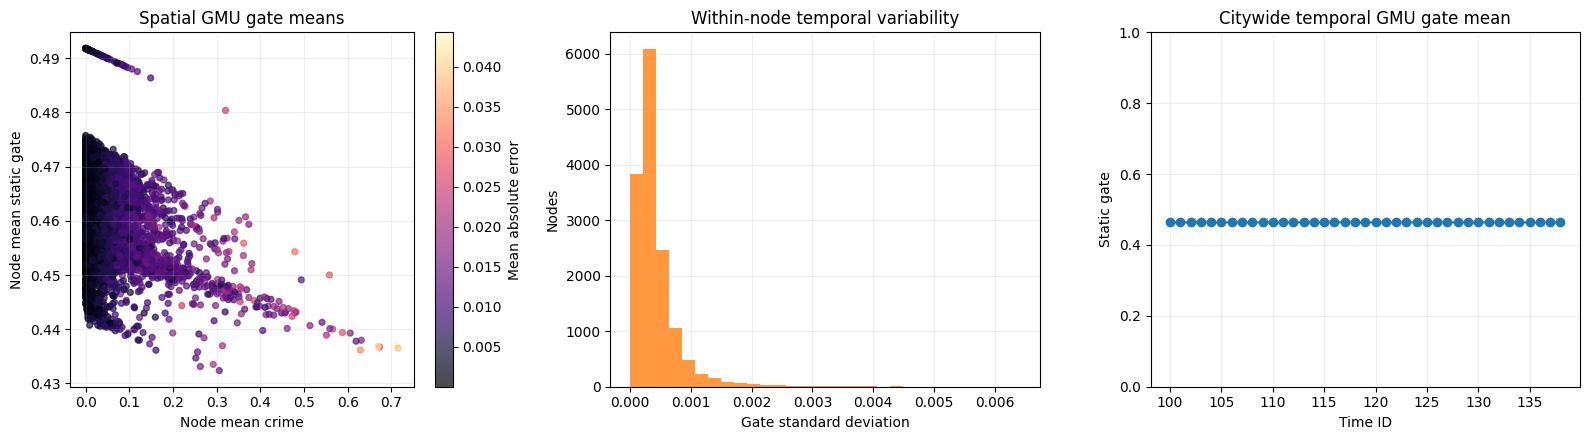

,node_id,gate_mean,gate_std,mean_crime,mean_absolute_error
13759,13759,0.455867,0.006414,0.361775,0.028851
8149,8149,0.446236,0.006119,0.321197,0.024231
10708,10708,0.448295,0.005942,0.310790,0.004679
5155,5155,0.446463,0.005937,0.279655,0.005153
2538,2538,0.462657,0.005852,0.227495,0.022855
11888,11888,0.445716,0.005256,0.399450,0.008323
1423,1423,0.463644,0.005003,0.285412,0.021172
3852,3852,0.458839,0.004937,0.219688,0.008746
6896,6896,0.446515,0.004851,0.350025,0.016431
12749,12749,0.451402,0.004778,0.191998,0.003307


In [49]:
gmu_node_stability = gmu_explain_frame.groupby("node_id").agg(
    gate_mean=("gmu_static_gate", "mean"), gate_std=("gmu_static_gate", "std"),
    mean_crime=("input_crime", "mean"), mean_absolute_error=("absolute_error", "mean"),
).reset_index()
gmu_time_stability = gmu_explain_frame.groupby("time_id").agg(
    gate_mean=("gmu_static_gate", "mean"), gate_std=("gmu_static_gate", "std"),
    mean_crime=("input_crime", "mean"),
).reset_index()

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
sc = axes[0].scatter(gmu_node_stability["mean_crime"], gmu_node_stability["gate_mean"],
                     c=gmu_node_stability["mean_absolute_error"], cmap="magma", s=18, alpha=0.7)
fig.colorbar(sc, ax=axes[0], label="Mean absolute error")
axes[0].set(title="Spatial GMU gate means", xlabel="Node mean crime", ylabel="Node mean static gate")
axes[1].hist(gmu_node_stability["gate_std"].dropna(), bins=30, color="tab:orange", alpha=0.8)
axes[1].set(title="Within-node temporal variability", xlabel="Gate standard deviation", ylabel="Nodes")
axes[2].plot(gmu_time_stability["time_id"], gmu_time_stability["gate_mean"], marker="o")
axes[2].set(title="Citywide temporal GMU gate mean", xlabel="Time ID", ylabel="Static gate", ylim=(0, 1))
for ax in axes: ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig(os.path.join(output_folder, "gmu_spatial_temporal_gate_stability.png"), dpi=300, bbox_inches="tight")
plt.show()
display(gmu_node_stability.sort_values("gate_std", ascending=False).head(10))
gmu_node_stability.to_csv(os.path.join(output_folder, "gmu_node_gate_stability.csv"), index=False)
gmu_time_stability.to_csv(os.path.join(output_folder, "gmu_time_gate_stability.csv"), index=False)

## I. GMU gate relationship with prediction error

This identifies associations between modality balance and difficult cases. It does not show
that changing the gate would necessarily reduce an error; the intervention test addresses
functional faithfulness more directly.

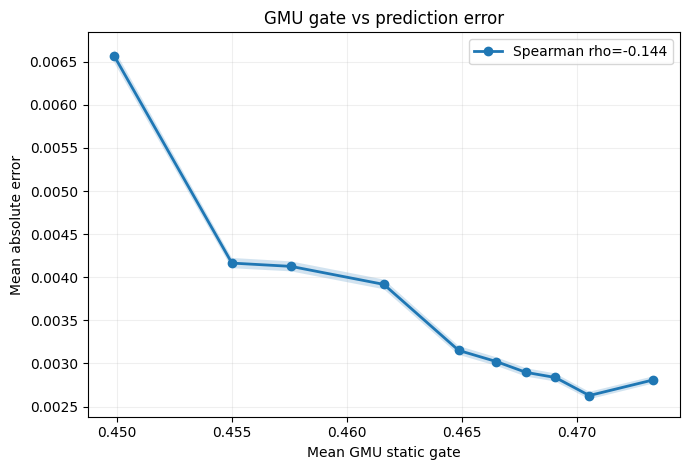

,role,pearson_r,pearson_p,spearman_rho,spearman_p
0,GMU,-0.15827,0.0,-0.14436,0.0


In [50]:
gmu_error_stats = association_stats(
    gmu_explain_frame["gmu_static_gate"], gmu_explain_frame["absolute_error"]
)
summary = binned_summary(gmu_explain_frame, "gmu_static_gate", "absolute_error", bins=10)
plt.figure(figsize=(7, 4.8))
plt.plot(summary["mean_x"], summary["mean_y"], marker="o", linewidth=2)
plt.fill_between(summary["mean_x"], summary["mean_y"]-summary["ci95"],
                 summary["mean_y"]+summary["ci95"], alpha=0.2)
plt.xlabel("Mean GMU static gate"); plt.ylabel("Mean absolute error")
plt.title("GMU gate vs prediction error")
plt.legend([f"Spearman rho={gmu_error_stats['spearman_rho']:.3f}"])
plt.grid(alpha=0.2); plt.tight_layout()
plt.savefig(os.path.join(output_folder, "gmu_gate_error_relationship.png"), dpi=300, bbox_inches="tight")
plt.show()
gmu_gate_error_association = pd.DataFrame([{"role": "GMU", **gmu_error_stats}])
display(gmu_gate_error_association.round(5))
gmu_gate_error_association.to_csv(os.path.join(output_folder, "gmu_gate_error_association.csv"), index=False)

## J. Single-gate intervention faithfulness

All trained weights remain fixed while the GMU gate logits are replaced. Fixed probabilities
are strong off-manifold interventions; shuffled logits are often the more credible test
because they preserve the learned logit distribution while breaking assignment to cases.

,intervention,MSE,RMSE,MAE,delta_MSE_vs_learned,relative_MSE_change_percent
0,Learned gate,0.00006,0.00759,0.00361,0.00000,0.00000
1,Balanced gate (0.5),0.00058,0.02407,0.01564,0.00052,906.22916
2,Static-heavy gate (0.95),0.00288,0.05369,0.03105,0.00282,4907.28693
3,Dynamic-heavy gate (0.05),0.00202,0.04492,0.02846,0.00196,3404.89454
4,Shuffled learned gate logits,0.00093,0.03043,0.02234,0.00087,1508.96726


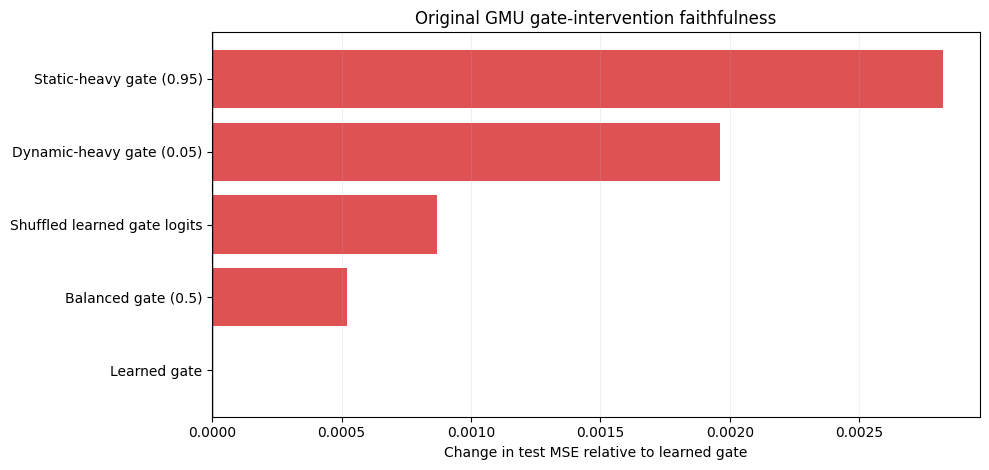

In [51]:
def _constant_logit_hook(probability):
    p = float(np.clip(probability, 1e-4, 1.0-1e-4))
    logit = math.log(p/(1.0-p))
    def hook(module, inputs, output):
        return torch.full_like(output, logit)
    return hook


def _shuffle_logit_hook(random_seed):
    counter = {"value": 0}
    def hook(module, inputs, output):
        generator = torch.Generator(device=output.device)
        generator.manual_seed(random_seed + counter["value"])
        counter["value"] += 1
        flat = output.reshape(-1)
        permutation = torch.randperm(flat.numel(), generator=generator, device=output.device)
        return flat[permutation].reshape_as(output)
    return hook


@contextlib.contextmanager
def gmu_gate_intervention(model, probability=None, shuffle=False, random_seed=42):
    handle = None
    try:
        if shuffle:
            handle = model.gmu.gate_layer.register_forward_hook(_shuffle_logit_hook(random_seed))
        elif probability is not None:
            handle = model.gmu.gate_layer.register_forward_hook(_constant_logit_hook(probability))
        yield
    finally:
        if handle is not None:
            handle.remove()


def evaluate_current_gmu(model, loader, device):
    model.eval(); pred_all, target_all = [], []
    with torch.no_grad():
        for data in loader:
            data = data.to(device)
            prediction, _ = model(data.x_static, data.x_dynamic, data.edge_index)
            target = data.y.float().view_as(prediction)
            pred_all.append(prediction.cpu()); target_all.append(target.cpu())
    prediction = torch.cat(pred_all).numpy(); target = torch.cat(target_all).numpy()
    error = prediction-target; mse = float(np.mean(error**2))
    return {"MSE": mse, "RMSE": float(np.sqrt(mse)), "MAE": float(np.mean(np.abs(error)))}


gmu_intervention_specs = [
    ("Learned gate", None, False),
    ("Balanced gate (0.5)", 0.5, False),
    ("Static-heavy gate (0.95)", 0.95, False),
    ("Dynamic-heavy gate (0.05)", 0.05, False),
    ("Shuffled learned gate logits", None, True),
]
gmu_intervention_rows = []
for label, probability, shuffle in gmu_intervention_specs:
    with gmu_gate_intervention(model, probability, shuffle, seed):
        row = evaluate_current_gmu(model, test_loader, device)
    gmu_intervention_rows.append({"intervention": label, **row})
gmu_gate_interventions = pd.DataFrame(gmu_intervention_rows)
gmu_baseline_mse = gmu_gate_interventions.loc[
    gmu_gate_interventions.intervention == "Learned gate", "MSE"
].iloc[0]
gmu_gate_interventions["delta_MSE_vs_learned"] = gmu_gate_interventions["MSE"]-gmu_baseline_mse
gmu_gate_interventions["relative_MSE_change_percent"] = (
    100*gmu_gate_interventions["delta_MSE_vs_learned"]/(gmu_baseline_mse+1e-12)
)
display(gmu_gate_interventions.round(5))

plot_df = gmu_gate_interventions.sort_values("delta_MSE_vs_learned")
plt.figure(figsize=(10, 4.8))
plt.barh(plot_df["intervention"], plot_df["delta_MSE_vs_learned"],
         color=["tab:green" if x <= 0 else "tab:red" for x in plot_df["delta_MSE_vs_learned"]], alpha=0.8)
plt.axvline(0, color="black", linewidth=1)
plt.xlabel("Change in test MSE relative to learned gate")
plt.title("Original GMU gate-intervention faithfulness")
plt.grid(axis="x", alpha=0.2); plt.tight_layout()
plt.savefig(os.path.join(output_folder, "gmu_gate_intervention_faithfulness.png"), dpi=300, bbox_inches="tight")
plt.show()
gmu_gate_interventions.to_csv(os.path.join(output_folder, "gmu_gate_interventions.csv"), index=False)

## K. Model-agnostic input permutation importance

This returns from latent gates to named socioeconomic features and temporal lags. An increase
in MSE after node-wise permutation indicates reliance by the frozen model. Correlated inputs
can share or redistribute importance, so rankings are not causal effects.

,modality,feature,baseline_MSE,permuted_MSE_mean,permuted_MSE_std,delta_MSE
15,dynamic,crime_lag_1,0.000058,0.004040,3.308779e-06,0.003982
14,dynamic,crime_lag_2,0.000058,0.000132,1.608970e-07,0.000074
12,dynamic,crime_lag_4,0.000058,0.000089,1.453383e-07,0.000032
11,dynamic,crime_lag_5,0.000058,0.000074,7.616461e-08,0.000017
13,dynamic,crime_lag_3,0.000058,0.000072,6.526941e-09,0.000015
0,static,Renda_media_por_domicilio,0.000058,0.000071,2.987164e-07,0.000013
9,static,Terminal_de_onibus,0.000058,0.000070,4.475710e-07,0.000012
6,static,maiores_de_65_anos_taxa,0.000058,0.000069,6.801438e-08,0.000012
3,static,Alfabetizados_de_7_a_15_anos,0.000058,0.000069,2.999153e-07,0.000012
7,static,Estacao_de_metro,0.000058,0.000066,2.968104e-07,0.000008


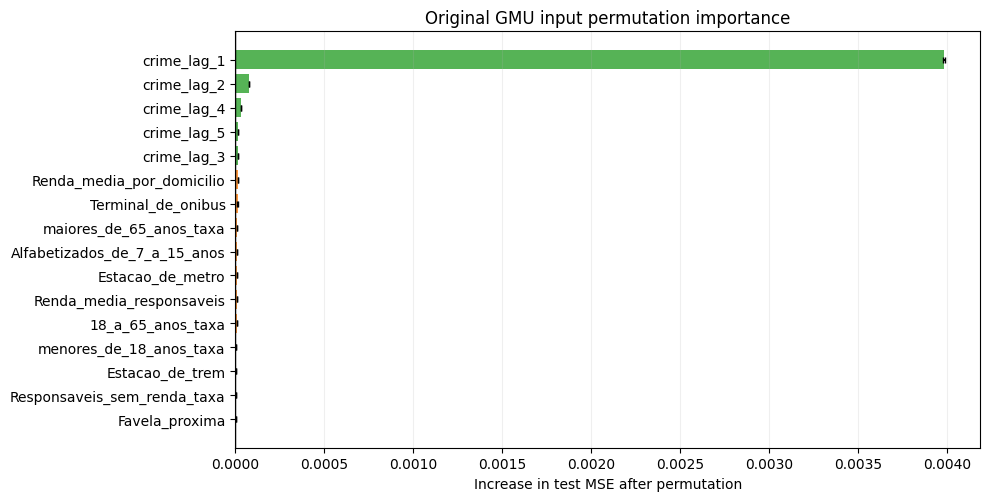

In [52]:
@torch.no_grad()
def gmu_permutation_importance(model, loader, device, static_names=None, repeats=3, random_seed=42):
    model.eval()
    baseline = evaluate_current_gmu(model, loader, device)["MSE"]
    sample = next(iter(loader))
    static_dim, dynamic_dim = sample.x_static.shape[1], sample.x_dynamic.shape[1]
    if static_names is None or len(static_names) != static_dim:
        static_names = [f"static_{i}" for i in range(static_dim)]
    dynamic_names = [f"crime_lag_{dynamic_dim-i}" for i in range(dynamic_dim)]
    rows = []
    for modality, dim, names in [("static", static_dim, static_names),
                                 ("dynamic", dynamic_dim, dynamic_names)]:
        for feature_index in range(dim):
            repeated_mse = []
            for repeat in range(repeats):
                pred_all, target_all = [], []
                generator = torch.Generator(device=device)
                generator.manual_seed(random_seed + 1000*feature_index + 17*repeat +
                                      (0 if modality == "static" else 100000))
                for data in loader:
                    data = data.to(device)
                    xs, xd = data.x_static.clone(), data.x_dynamic.clone()
                    permutation = torch.randperm(xs.shape[0], generator=generator, device=device)
                    if modality == "static": xs[:, feature_index] = xs[permutation, feature_index]
                    else: xd[:, feature_index] = xd[permutation, feature_index]
                    prediction, _ = model(xs, xd, data.edge_index)
                    pred_all.append(prediction.cpu()); target_all.append(data.y.float().view_as(prediction).cpu())
                prediction = torch.cat(pred_all).numpy(); target = torch.cat(target_all).numpy()
                repeated_mse.append(float(np.mean((prediction-target)**2)))
            rows.append({
                "modality": modality, "feature": names[feature_index], "baseline_MSE": baseline,
                "permuted_MSE_mean": np.mean(repeated_mse),
                "permuted_MSE_std": np.std(repeated_mse, ddof=1) if repeats > 1 else 0.0,
                "delta_MSE": np.mean(repeated_mse)-baseline,
            })
    return pd.DataFrame(rows)


static_feature_names = list(static_dt.columns) if len(static_dt.columns) == S else None
gmu_permutation_table = gmu_permutation_importance(
    model, test_loader, device, static_names=static_feature_names, repeats=3, random_seed=seed
)
display(gmu_permutation_table.sort_values("delta_MSE", ascending=False).head(15))
plot_df = gmu_permutation_table.sort_values("delta_MSE", ascending=True)
plt.figure(figsize=(10, max(5, 0.32*len(plot_df))))
plt.barh(plot_df["feature"], plot_df["delta_MSE"], xerr=plot_df["permuted_MSE_std"],
         color=plot_df["modality"].map({"static": "tab:orange", "dynamic": "tab:green"}),
         alpha=0.8, capsize=2)
plt.axvline(0, color="black", linewidth=1)
plt.xlabel("Increase in test MSE after permutation")
plt.title("Original GMU input permutation importance")
plt.grid(axis="x", alpha=0.2); plt.tight_layout()
plt.savefig(os.path.join(output_folder, "gmu_input_permutation_importance.png"), dpi=300, bbox_inches="tight")
plt.show()
gmu_permutation_table.to_csv(os.path.join(output_folder, "gmu_input_permutation_importance.csv"), index=False)

## L. Time-cluster bootstrap confidence intervals

The bootstrap resamples complete test windows so all nodes from a selected time remain
together. These intervals capture test-window variation, not random initialization or
training uncertainty; multiple matched seeds are still required.

,quantity,estimate,bootstrap_ci95_low,bootstrap_ci95_high,bootstrap_std
0,gate_mean,0.46363,0.46362,0.46363,0.00000
1,effective_static,0.89293,0.89279,0.89308,0.00008
2,gate_crime_spearman,-0.27526,-0.27632,-0.27412,0.00058


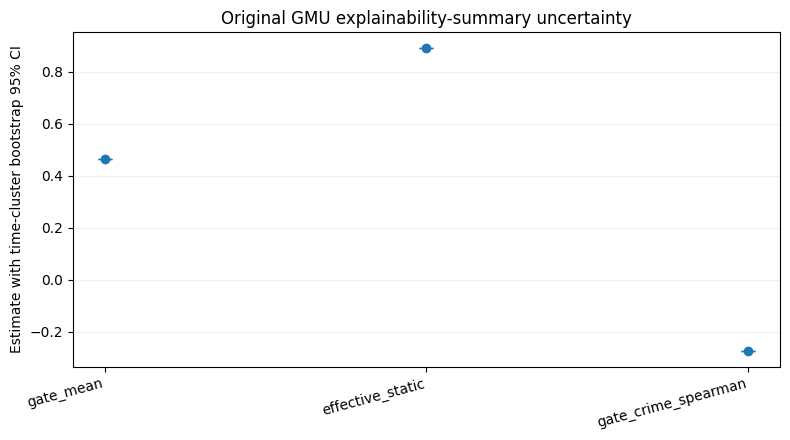

In [53]:
def gmu_cluster_bootstrap(frame, cluster_col="time_id", n_bootstrap=1000, random_seed=42):
    rng = np.random.default_rng(random_seed)
    clusters = frame[cluster_col].drop_duplicates().to_numpy()
    estimates = []
    for _ in range(n_bootstrap):
        sampled = rng.choice(clusters, size=len(clusters), replace=True)
        boot = pd.concat([frame.loc[frame[cluster_col] == c] for c in sampled], ignore_index=True)
        estimates.append({
            "gate_mean": boot["gmu_static_gate"].mean(),
            "effective_static": boot["static_activation_proportion"].mean(),
            "gate_crime_spearman": association_stats(
                boot["input_crime"], boot["gmu_static_gate"]
            )["spearman_rho"],
        })
    samples = pd.DataFrame(estimates)
    point = {
        "gate_mean": frame["gmu_static_gate"].mean(),
        "effective_static": frame["static_activation_proportion"].mean(),
        "gate_crime_spearman": association_stats(
            frame["input_crime"], frame["gmu_static_gate"]
        )["spearman_rho"],
    }
    summary = pd.DataFrame([{
        "quantity": col, "estimate": point[col],
        "bootstrap_ci95_low": samples[col].quantile(0.025),
        "bootstrap_ci95_high": samples[col].quantile(0.975),
        "bootstrap_std": samples[col].std(ddof=1),
    } for col in samples.columns])
    return summary, samples


gmu_bootstrap_summary, gmu_bootstrap_samples = gmu_cluster_bootstrap(
    gmu_explain_frame, n_bootstrap=1000, random_seed=seed
)
display(gmu_bootstrap_summary.round(5))
plt.figure(figsize=(8, 4.5))
x = np.arange(len(gmu_bootstrap_summary))
lower = gmu_bootstrap_summary["estimate"]-gmu_bootstrap_summary["bootstrap_ci95_low"]
upper = gmu_bootstrap_summary["bootstrap_ci95_high"]-gmu_bootstrap_summary["estimate"]
plt.errorbar(x, gmu_bootstrap_summary["estimate"], yerr=np.vstack([lower, upper]),
             fmt="o", capsize=5, linewidth=2)
plt.xticks(x, gmu_bootstrap_summary["quantity"], rotation=15, ha="right")
plt.ylabel("Estimate with time-cluster bootstrap 95% CI")
plt.title("Original GMU explainability-summary uncertainty")
plt.grid(axis="y", alpha=0.2); plt.tight_layout()
plt.savefig(os.path.join(output_folder, "gmu_gate_bootstrap_ci.png"), dpi=300, bbox_inches="tight")
plt.show()
gmu_bootstrap_summary.to_csv(os.path.join(output_folder, "gmu_gate_bootstrap_ci.csv"), index=False)

## M. Exportable summary for fair GMU–M11 comparison

Common columns below can be compared across models. M11 should export separate self and
neighbor rows or a declared primary role; GMU has exactly one row. Never fill absent GMU
self/neighbor statistics with invented values.

In [54]:
learned_row = gmu_gate_interventions.query("intervention == 'Learned gate'").iloc[0]
balanced_row = gmu_gate_interventions.query("intervention == 'Balanced gate (0.5)'").iloc[0]
shuffled_row = gmu_gate_interventions.query("intervention == 'Shuffled learned gate logits'").iloc[0]
input_assoc = gmu_gate_crime_associations.query("crime_variable == 'input_crime'").iloc[0]

gmu_model_explainability_summary = pd.DataFrame([{
    "model": "Original GMU only",
    "uses_graph": False,
    "gate_role": "single_pre_regression_fusion_gate",
    "test_MSE": metrics["MSE"], "test_RMSE": metrics["RMSE"],
    "test_MAE": metrics["MAE"], "test_R2": metrics["R2"],
    "static_only_MSE": static_metrics["MSE"], "dynamic_only_MSE": dynamic_metrics["MSE"],
    "static_gate_mean": gmu_explain_frame["gmu_static_gate"].mean(),
    "gate_std_featurewise": gmu_gate_health["global_std"].iloc[0],
    "gate_entropy": gmu_gate_health["mean_entropy_0_to_1"].iloc[0],
    "gate_input_crime_spearman": input_assoc["spearman_rho"],
    "effective_static_proportion": gmu_explain_frame["static_activation_proportion"].mean(),
    "balanced_gate_delta_MSE": balanced_row["MSE"]-learned_row["MSE"],
    "shuffled_gate_delta_MSE": shuffled_row["MSE"]-learned_row["MSE"],
    "self_neighbor_analysis_available": False,
}])
display(gmu_model_explainability_summary.T)
gmu_model_explainability_summary.to_csv(
    os.path.join(output_folder, "gmu_professional_model_explainability_summary.csv"), index=False
)

,0
model,Original GMU only
uses_graph,False
gate_role,single_pre_regression_fusion_gate
test_MSE,0.000058
test_RMSE,0.007587
test_MAE,0.003611
test_R2,0.980158
static_only_MSE,0.003624
dynamic_only_MSE,0.000126
static_gate_mean,0.463626


## Interpretation framework after running the notebook

Use prediction and explanation evidence separately:

1. **Predictive quality:** report MSE, RMSE, MAE and R² across matched seeds.
2. **Complementarity:** compare full input with post-hoc ablations and independently trained
   unimodal baselines.
3. **Gate health:** reject collapse only when gates vary and interventions are faithful.
4. **Conditional behavior:** report gate–crime effect sizes, not p-values alone.
5. **Mechanistic scale:** compare raw gates with effective activation proportions.
6. **Faithfulness:** emphasize shuffled-gate degradation over extreme fixed-gate results.
7. **Original-feature evidence:** use permutation importance while acknowledging correlation.
8. **Uncertainty:** time bootstrap does not replace 5–10 matched training seeds.

For the final GMU–M11 comparison, use identical preprocessing, chronological splits, training
selection rules, hidden dimension, optimizer search policy, seeds and prediction metrics.
M11-specific self/neighbor evidence should be reported as an additional architectural
capability, not as a missing score assigned to GMU.

## Standard publication-comparison export

This template intentionally contains `NaN` metrics until a clean rerun supplies values from the restored checkpoint. Architecture-inapplicable fields must remain `NaN`, not fabricated.


In [ ]:
# Standard final comparison record (self-contained checkpoint reload).
checkpoint_path = os.path.join(
    checkpoint_dir, f"{model_used}__seed-{seed}__best-val.pt"
)
if not os.path.exists(checkpoint_path):
    raise FileNotFoundError(
        f"Standardized checkpoint not found: {checkpoint_path}. "
        "Run the training cell first."
    )

checkpoint_device = next(model.parameters()).device
checkpoint = torch.load(
    checkpoint_path, map_location=checkpoint_device, weights_only=False
)
model.load_state_dict(checkpoint["model_state_dict"])
if "optimizer_state_dict" in checkpoint:
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
model.eval()
execution_status = "EXECUTED_FROM_STANDARDIZED_BEST_CHECKPOINT"

metric_candidates = [
    globals().get("metrics"),
    globals().get("scalar_metrics"),
    globals().get("hierarchical_metrics"),
    globals().get("test_metrics"),
]
final_metrics = next((m for m in metric_candidates if isinstance(m, dict)), None)
if final_metrics is None:
    raise RuntimeError("No final metric dictionary is available; run final test evaluation first.")

def _metric(name):
    for key, value in final_metrics.items():
        if str(key).lower().replace("²", "2") == name:
            return float(value)
    return np.nan

publication_comparison_summary = pd.DataFrame([{
    "model": model_used,
    "seed": seed,
    "split": split_type,
    "n_windows": len(test_dataset),
    "n_nodes": int(static_tensor.shape[0]),
    "n_cases": int(len(test_dataset) * static_tensor.shape[0]),
    "mse": _metric("mse"),
    "rmse": _metric("rmse"),
    "mae": _metric("mae"),
    "r2": _metric("r2"),
    "huber": _metric("huber"),
    "uses_graph": False,
    "execution_status": execution_status,
}])

publication_comparison_summary.to_csv(
    os.path.join(csv_dir, f"{model_used}__seed-{seed}__summary.csv"), index=False
)
display(publication_comparison_summary)


,model,seed,split,n_windows,n_nodes,n_cases,mse,rmse,mae,r2,huber,uses_graph,execution_status
0,Original_GMU_Only_Complete_Explainability,42,chronological_transductive,39,14640,570960,0.000058,0.007587,0.003611,0.980158,NaN,False,EXECUTED_FROM_STANDARDIZED_BEST_CHECKPOINT


: 